 # NYC Yellow Taxi Trip Project - Machine Learning 2024

# 1. Introduction

## 1.1 New York City Taxi Trip Dataset

The dataset used were collected and provided to the NYC Taxi and Limousine Commission (TLC).

New York City (NYC) Taxi & Limousine Commission (TLC) keeps data from all its cabs, and it is freely available to download from its official website. Now, the TLC primarily keeps and manages data for 4 different types of vehicles: Yellow Taxi, Green Taxi and For-Hire Vehicles (FHVs).

New York City (NYC) is one of the world’s largest metropolises, and its public transportation system is among the busiest and most complex. In NYC taxis play a critical role in providing fast and flexible transportation services, filling gaps that may not be accessible through the subway and bus systems. The number of taxicabs is limited by a finite number of medallions issued by the TLC. The pickups are not pre-arranged.

## 1.2 Objectives of this project

- Predicting taxi fare based on trip data
- Predicting trip duration
- Predicting the pickup density based on trip data

For the purpose of this project, we will consider the data for 1 months as following: Feb 2016

# 2. Dataset Description

- Pickup_longitude: Longitude where the meter was engaged
- Pickup_latitude: Latitude where the meter was engaged
- Pickup_datetime: The date and time when the meter was engaged
- Dropoff_datetime: The date and time when the meter was disengaged
- Trip_distance: The elapsed trip distance in miles reported by the taximeter
- Fare_amount: The time-and-distance fare calculated by the meter
- Passenger_count: The number of passengers in the vehicle. This is a driver-entered value.
- Payment_type: A numeric code signifying how the passenger paid for the trip. Payment type (6): Credit card, Cash, No charge, Dispute, Unknown, Voided trip
- Extra: Miscellaneous extras and surcharges. Currently, this only includes the 0.50 and 1 rush hour and overnight charges.
- Total_amount: The total amount charged to passengers. Does not include cash tips.
- RateCodeID:The final rate code in effect at the end of the trip. Standard rate, JFK, Newark, Nassau or Westchester, Negotiated fare, Group ride.

# 3. Data Cleaning and Preprocessing

In [53]:
# importing librairy
!pip install pandas
import pandas as pd
import datetime
import os

In [54]:
# Loading dataset
df = pd.read_csv("yellow_tripdata_2016-02.csv")
df.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2016-02-25 17:24:20,2016-02-25 17:27:20,2,0.70,-73.947250,40.763771,1,N,-73.992012,40.735390,2,5.0,0.0,0.5,0.00,0.0,0.3,5.80
1,2,2016-02-25 23:10:50,2016-02-25 23:31:50,2,5.52,-73.983017,40.750992,1,N,-73.988586,40.758839,2,20.0,0.5,0.5,0.00,0.0,0.3,21.30
2,2,2016-02-01 00:00:01,2016-02-01 00:10:52,6,1.99,-73.992340,40.758202,1,N,-73.964355,40.757977,1,9.5,0.5,0.5,0.70,0.0,0.3,11.50
3,1,2016-02-01 00:00:04,2016-02-01 00:05:16,1,1.50,-73.981453,40.749722,1,N,-73.982323,40.763985,2,6.5,0.5,0.5,0.00,0.0,0.3,7.80
4,2,2016-02-01 00:00:05,2016-02-01 00:20:59,1,5.60,-74.000603,40.729755,1,N,-73.951324,40.669834,1,20.0,0.5,0.5,4.00,0.0,0.3,25.30
5,2,2016-02-01 00:00:06,2016-02-01 00:15:01,1,4.69,-74.005104,40.719006,1,N,-73.947090,40.688885,2,16.0,0.5,0.5,0.00,0.0,0.3,17.30
6,2,2016-02-01 00:00:09,2016-02-01 00:05:35,1,1.45,-73.986000,40.762146,1,N,-73.990608,40.746208,1,6.5,0.5,0.5,1.56,0.0,0.3,9.36
7,2,2016-02-01 00:00:19,2016-02-01 00:06:35,1,1.10,-73.966331,40.773422,1,N,-73.956108,40.781422,2,6.5,0.5,0.5,0.00,0.0,0.3,7.80
8,2,2016-02-01 00:00:21,2016-02-01 00:06:32,1,1.96,-73.976555,40.765697,1,N,-73.978973,40.744381,1,7.5,0.5,0.5,1.00,0.0,0.3,9.80
9,2,2016-02-01 00:00:21,2016-02-01 00:16:59,2,4.50,-73.976585,40.764931,1,N,-73.911118,40.768909,2,16.0,0.5,0.5,0.00,0.0,0.3,17.30


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11382049 entries, 0 to 11382048
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        int64  
 4   trip_distance          float64
 5   pickup_longitude       float64
 6   pickup_latitude        float64
 7   RatecodeID             int64  
 8   store_and_fwd_flag     object 
 9   dropoff_longitude      float64
 10  dropoff_latitude       float64
 11  payment_type           int64  
 12  fare_amount            float64
 13  extra                  float64
 14  mta_tax                float64
 15  tip_amount             float64
 16  tolls_amount           float64
 17  improvement_surcharge  float64
 18  total_amount           float64
dtypes: float64(12), int64(4), object(3)
memory usage: 1.6+ GB


- 16 columns are numerical
- 3 columns are identified as text: tpep_pickup_datetime, tpep_dropoff_datetime and store_and_fwd_flag
- We need to convert tpep_pickup_datetime, tpep_dropoff_datetime to datetime
- Observations: 11'382'049
- Variables: 19

In [57]:
print("Observations: ", df.shape[0])

print("Variables: ", df.shape[1])

Observations:  11382049
Variables:  19


In [58]:
#Show % of missing values in each variable

(df.isna().sum()/df.shape[0]*100).sort_values(ascending=False)

VendorID                 0.0
tpep_pickup_datetime     0.0
tpep_dropoff_datetime    0.0
passenger_count          0.0
trip_distance            0.0
pickup_longitude         0.0
pickup_latitude          0.0
RatecodeID               0.0
store_and_fwd_flag       0.0
dropoff_longitude        0.0
dropoff_latitude         0.0
payment_type             0.0
fare_amount              0.0
extra                    0.0
mta_tax                  0.0
tip_amount               0.0
tolls_amount             0.0
improvement_surcharge    0.0
total_amount             0.0
dtype: float64

- There is 0% of missing values

In [60]:
#Dropping irrelevant columns
columns_drop = ['store_and_fwd_flag', 'payment_type', 'total_amount', 'mta_tax', 'improvement_surcharge', 'extra', 'VendorID', 'tolls_amount']

# Drop the columns from the Df
df = df.drop(columns=columns_drop)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11382049 entries, 0 to 11382048
Data columns (total 11 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   tpep_pickup_datetime   object 
 1   tpep_dropoff_datetime  object 
 2   passenger_count        int64  
 3   trip_distance          float64
 4   pickup_longitude       float64
 5   pickup_latitude        float64
 6   RatecodeID             int64  
 7   dropoff_longitude      float64
 8   dropoff_latitude       float64
 9   fare_amount            float64
 10  tip_amount             float64
dtypes: float64(7), int64(2), object(2)
memory usage: 955.2+ MB


In [68]:
# Optimize memory to run faster
def optimize_memory(df):
    # Convert float
    float_cols = df.select_dtypes(include=['float64']).columns
    df[float_cols] = df[float_cols].astype('float32')

    # Convert int
    int_cols = df.select_dtypes(include=['int64']).columns
    df[int_cols] = df[int_cols].astype('int32')

    return df

df = optimize_memory(df)

## 3.2 Handling of Inconsistent Data & Filtering

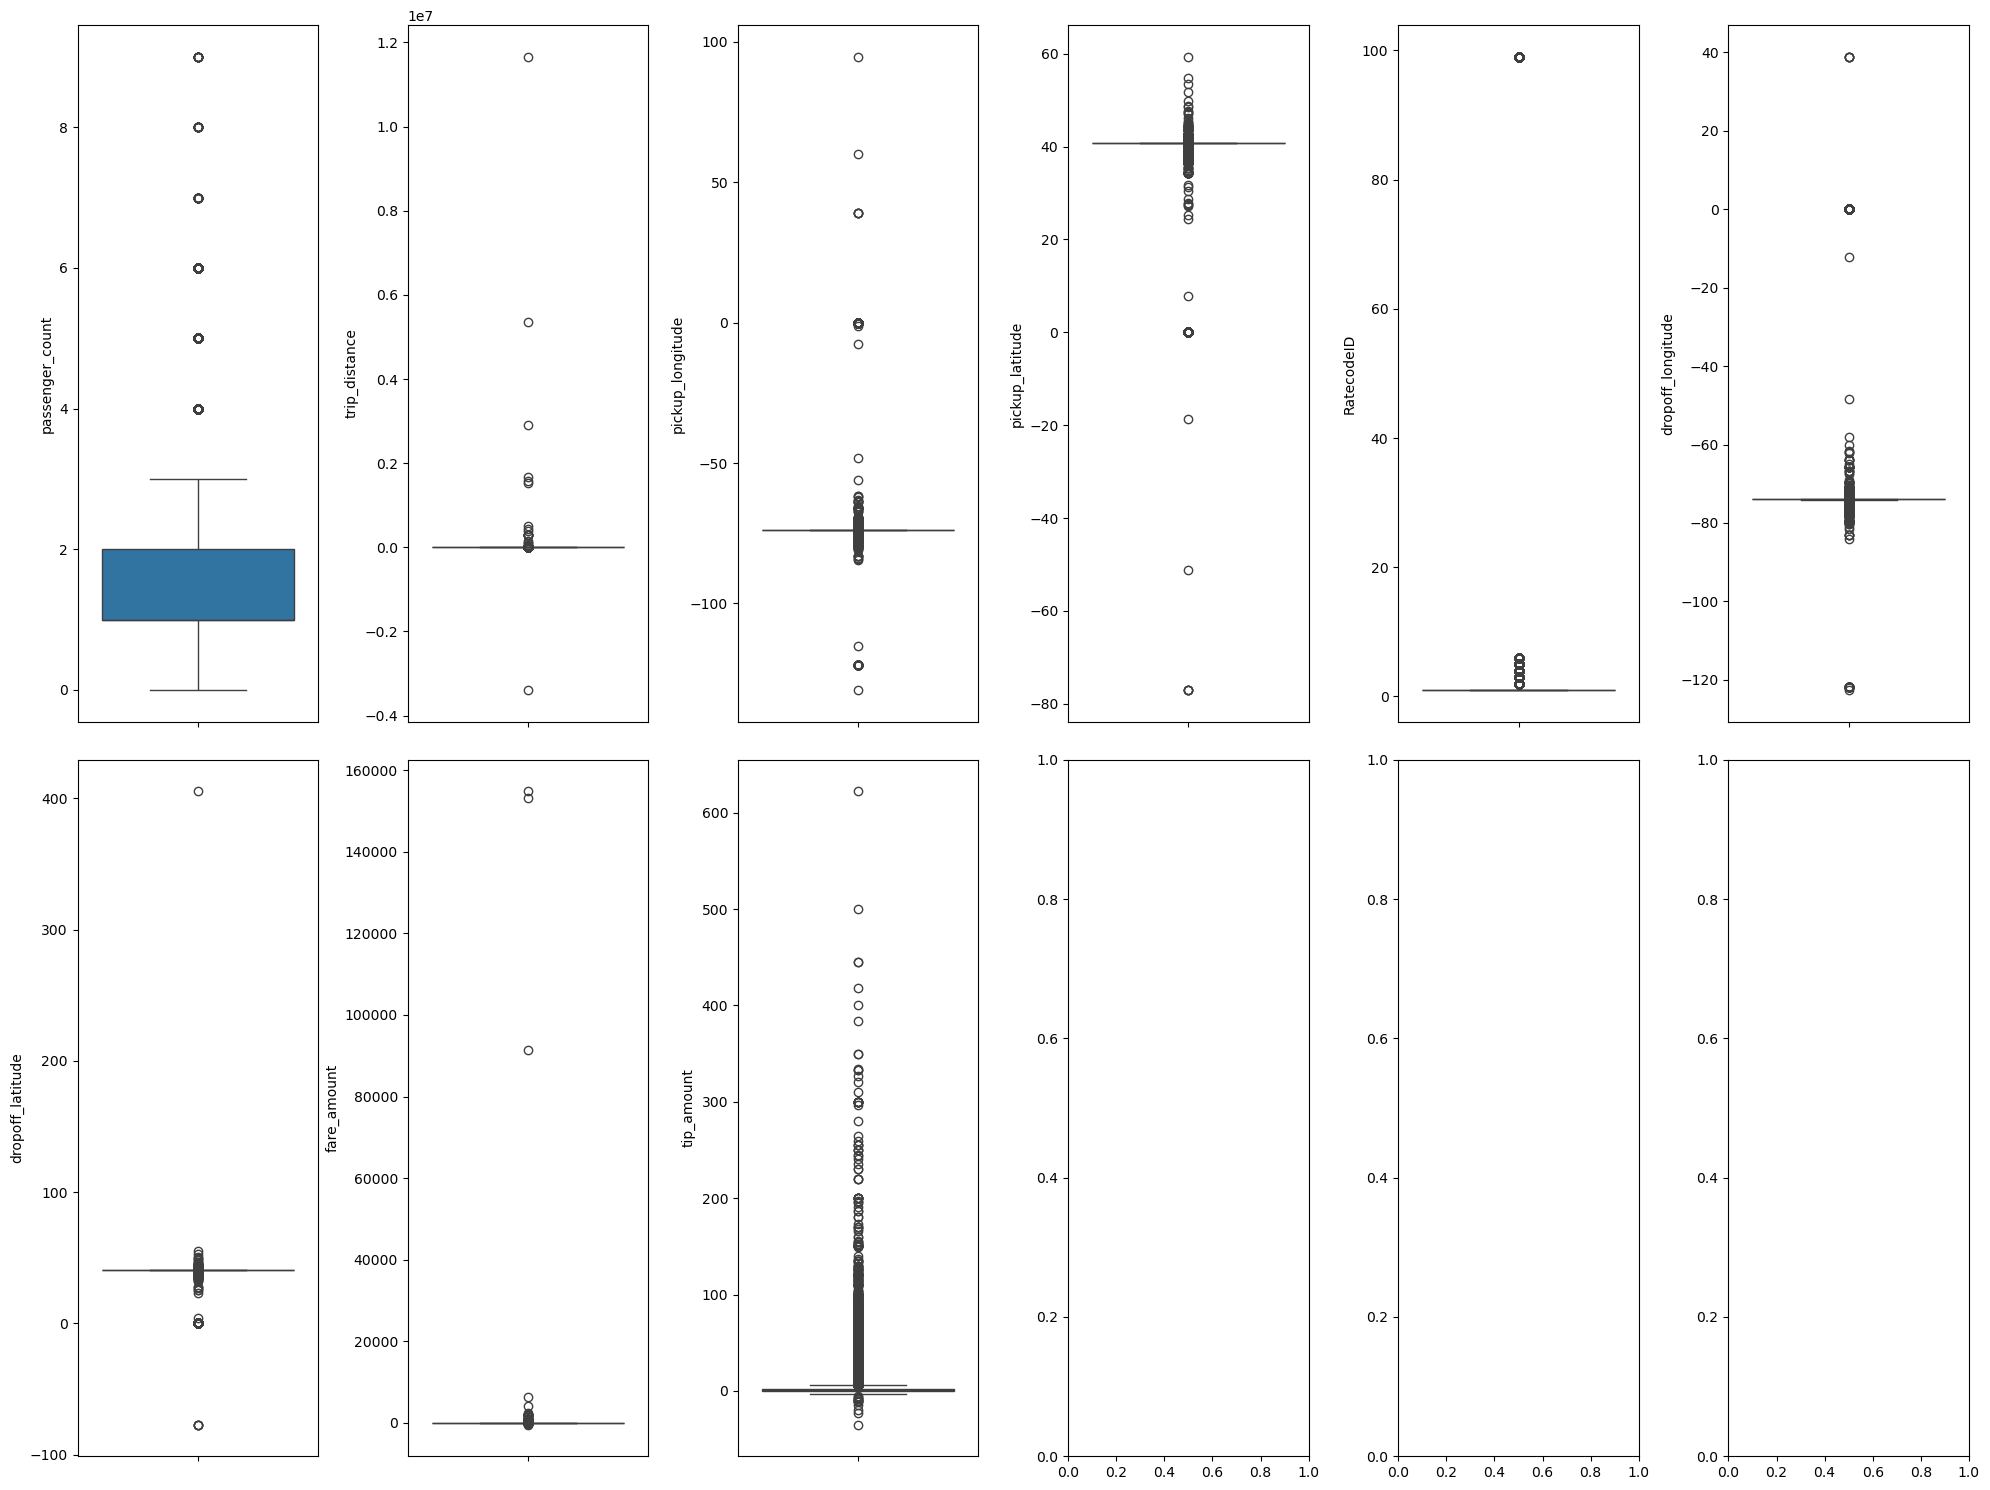

In [75]:
#Visualizing inconsistent data

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(ncols=6, nrows=2, figsize=(20,15))
index = 0
axs = axs.flatten()
for k, v in df.select_dtypes(include=[np.number]).items():
    sns.boxplot(y=k, data=df, ax=axs[index])
    index += 1
plt.tight_layout(w_pad=0.5, h_pad=2)

In [88]:
# Dropping Inconsistent value in Fare Amount
dup_negatif_val = df[df['fare_amount']<0]
dup_negatif_val 
df.drop(dup_negatif_val.index, inplace=True)

# Dropping 0 passenger_count
df = df[df['passenger_count'] > 0].reset_index(drop=True)

# Dropping Dupplicate values
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicate rows: 1


- New York is bounded by the location cordinates(lat,long) - (40.5774, -74.15) & (40.9176,-73.7004) so hence any cordinates not within these cordinates are not considered by us as I am only concerned with pickups and dropoff which originate within New York.

In [100]:
# Drop all the points outside the bounding box of newyork city for pickups

df = df[~((df.pickup_longitude <= -74.15) | (df.pickup_latitude <= 40.5774) | \
              (df.pickup_longitude >= -73.7004) | (df.pickup_latitude >= 40.9176))]

# Reinitialize index after suppression
df = df.reset_index(drop=True)


# Drop all the points outside the bounding box of newyork city for dropoff
df = df[~((df.dropoff_longitude <= -74.15) | (df.dropoff_latitude <= 40.5774) | \
              (df.dropoff_longitude >= -73.7004) | (df.dropoff_latitude >= 40.9176))]

# Reinitialize index after suppression
df = df.reset_index(drop=True)

In [93]:
df.describe()

,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,dropoff_longitude,dropoff_latitude,fare_amount,tip_amount
count,1.137724e+07,1.137724e+07,1.137724e+07,1.137724e+07,1.137724e+07,1.137724e+07,1.137724e+07,1.137724e+07,1.137724e+07
mean,1.655194e+00,5.062703e+00,-7.282713e+01,4.011915e+01,1.036923e+00,-7.288972e+01,4.015456e+01,1.242208e+01,1.773092e+00
std,1.311846e+00,4.123845e+03,1.058010e+01,5.473157e+00,5.221931e-01,1.044626e+01,5.390544e+00,7.068692e+01,2.502085e+00
min,1.000000e+00,-3.390584e+06,-1.308291e+02,-7.703949e+01,1.000000e+00,-1.226153e+02,-7.703949e+01,0.000000e+00,-7.000000e-02
25%,1.000000e+00,1.000000e+00,-7.399171e+01,4.073640e+01,1.000000e+00,-7.399126e+01,4.073463e+01,6.500000e+00,0.000000e+00
50%,1.000000e+00,1.660000e+00,-7.398160e+01,4.075338e+01,1.000000e+00,-7.397968e+01,4.075377e+01,9.000000e+00,1.350000e+00
75%,2.000000e+00,3.050000e+00,-7.396680e+01,4.076789e+01,1.000000e+00,-7.396230e+01,4.076935e+01,1.400000e+01,2.350000e+00
max,9.000000e+00,1.165853e+07,9.464387e+01,5.934835e+01,9.900000e+01,3.889659e+01,4.053167e+02,1.548104e+05,6.221100e+02


In [104]:
# Fixing unrealistic values for fare amount
for col in ['fare_amount']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

# Fixing unrealistic value for trip distance and Capping outliers
for col in ['trip_distance']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

In [108]:
# Showing calculation for finding outliers with IQR
import numpy as np

def find_outliers_IQR(df):

   q1=df.quantile(0.25)

   q3=df.quantile(0.75)

   IQR=q3-q1

   outliers = df[((df<(q1-1.5*IQR)) | (df>(q3+1.5*IQR)))]

   return outliers

# Finding outliers for passenger count
outliers = find_outliers_IQR(df['passenger_count'])

print("number of outliers: "+ str(len(outliers)))

print("max outlier value: "+ str(outliers.max()))

print("min outlier value: "+ str(outliers.min()))

outliers

number of outliers: 1179681
max outlier value: 9
min outlier value: 4


2           6
15          5
19          5
20          4
27          5
           ..
11154566    6
11154573    6
11154581    4
11154601    4
11154617    4
Name: passenger_count, Length: 1179681, dtype: int32

In [112]:
# Finding outliers for trip_distance
outliers = find_outliers_IQR(df['trip_distance'])

print("number of outliers: "+ str(len(outliers)))

print("max outlier value: "+ str(outliers.max()))

print("min outlier value: "+ str(outliers.min()))

outliers

number of outliers: 1
max outlier value: -2.0450000762939453
min outlier value: -2.0450000762939453


4166134   -2.045
Name: trip_distance, dtype: float32

In [116]:
# Finding outliers for passenger count
outliers = find_outliers_IQR(df['fare_amount'])

print("number of outliers: "+ str(len(outliers)))

print("max outlier value: "+ str(outliers.max()))

print("min outlier value: "+ str(outliers.min()))

outliers

number of outliers: 0
max outlier value: nan
min outlier value: nan


Series([], Name: fare_amount, dtype: float32)

- As per the above cells, there are a lot of outliers that we removed.
- After identifying the outliers, we decided what to do with them. It depends on the severity of outliers and the goals of our analysis. Since we think that most ouliers in the passenger_count was caused by human error, we should treat that outlier differently than the outliers for fare_amount and trip distance. It depends on wether or not the model would learn anything new by allowing the outliers to remain. This is why we choose:

- Drop the outliers for passenger_count that are 0; and for negative fare_amount; and pickup and dropoffs latitude and longitude that are outside nyc bound location
- Cap the outliers for fare_amount and trip distance
- Replace outliers using imputation as if they were missing values -> none for now but possibly for trip_distance (as a new feature)

In [121]:
# convert pickup and dropoff to datetime
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11154630 entries, 0 to 11154629
Data columns (total 11 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[ns]
 1   tpep_dropoff_datetime  datetime64[ns]
 2   passenger_count        int32         
 3   trip_distance          float32       
 4   pickup_longitude       float32       
 5   pickup_latitude        float32       
 6   RatecodeID             int32         
 7   dropoff_longitude      float32       
 8   dropoff_latitude       float32       
 9   fare_amount            float32       
 10  tip_amount             float32       
dtypes: datetime64[ns](2), float32(7), int32(2)
memory usage: 553.2 MB


## 3.3 Adding Features

In [126]:
# Adding trip_duration column
df['trip_duration_minutes'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

# Adding categories for RatecodeID
df['RatecodeID'] = df['RatecodeID'].replace({1:'Standard rate', 2:'JFK Airport', 3:'Newark Airport', 4:'Nassau or Westchester', 5:'Negotiated fare', 6:'Group ride'})
df['RatecodeID'].value_counts()

# Adding categories for Datetime data
time_bins = [0, 5, 11, 15, 20, 24] 
time_labels = ['Midnight', 'Morning', 'Noon', 'Evening', 'Night']
df['pickup_time'] = pd.cut(df['tpep_pickup_datetime'].dt.hour, bins=time_bins, labels=time_labels, right=False)

df['day_category'] = df['tpep_pickup_datetime'].dt.day_name().apply(lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekdays')


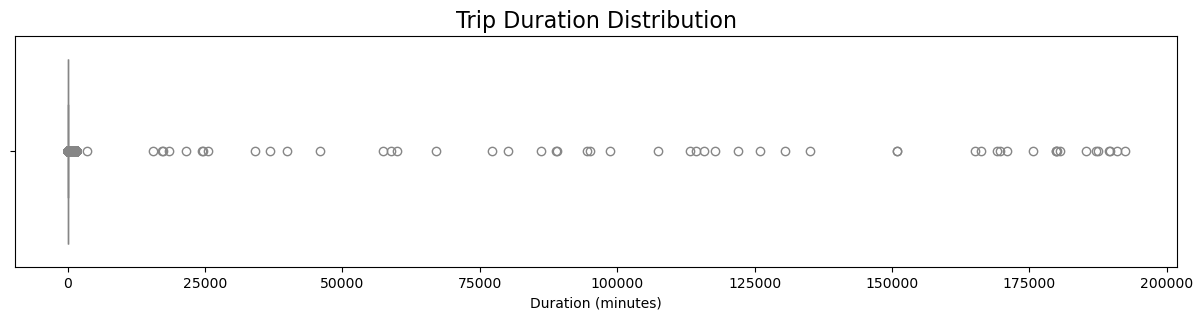

In [136]:
dup_negatif_val = df[df['trip_duration_minutes']<0]
dup_negatif_val 
df.drop(dup_negatif_val.index, inplace=True)


plt.figure(figsize=(15, 3))

sns.boxplot(data=df, x='trip_duration_minutes', color='pink')
plt.xlabel('Duration (minutes)')
plt.title('Trip Duration Distribution', fontsize=16)


plt.show()

In [140]:
# count how many trip duration is equal to 0
zero_duration_count = (df['trip_duration_minutes'] == 0).sum()

print(f"Number of trip equal to 0 duration : {zero_duration_count}")

Number of trip equal to 0 duration : 296


- Trip duration = 0 will be replaced by median

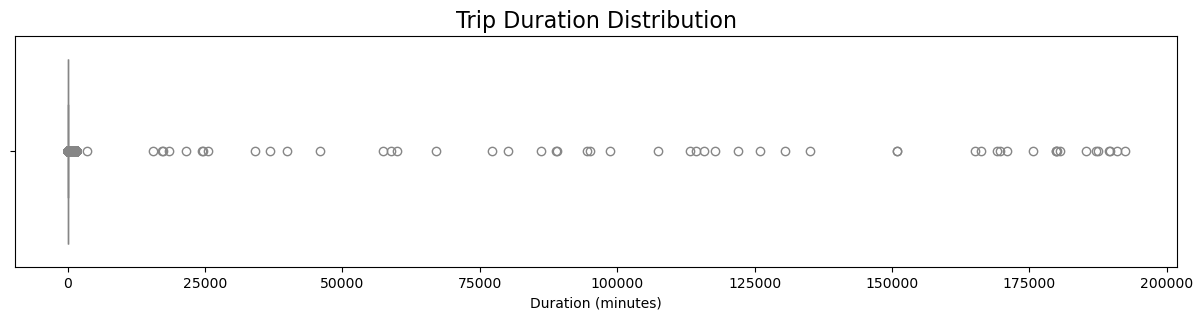

In [146]:
# Replacing 0 minutes trip duration with median
df['trip_duration_minutes'] = df['trip_duration_minutes'].replace(0, df['trip_duration_minutes'].median())

plt.figure(figsize=(15, 3))

sns.boxplot(data=df, x='trip_duration_minutes', color='pink')
plt.xlabel('Duration (minutes)')
plt.title('Trip Duration Distribution', fontsize=16)


plt.show()

In [148]:
# count how many trip duration is equal to 0
zero_duration_count = (df['trip_duration_minutes'] == 0).sum()

print(f"Number of trip equal to 0 duration : {zero_duration_count}")

Number of trip equal to 0 duration : 0


In [150]:
# Capping extreme outliers for trip duration
for col in ['trip_duration_minutes']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

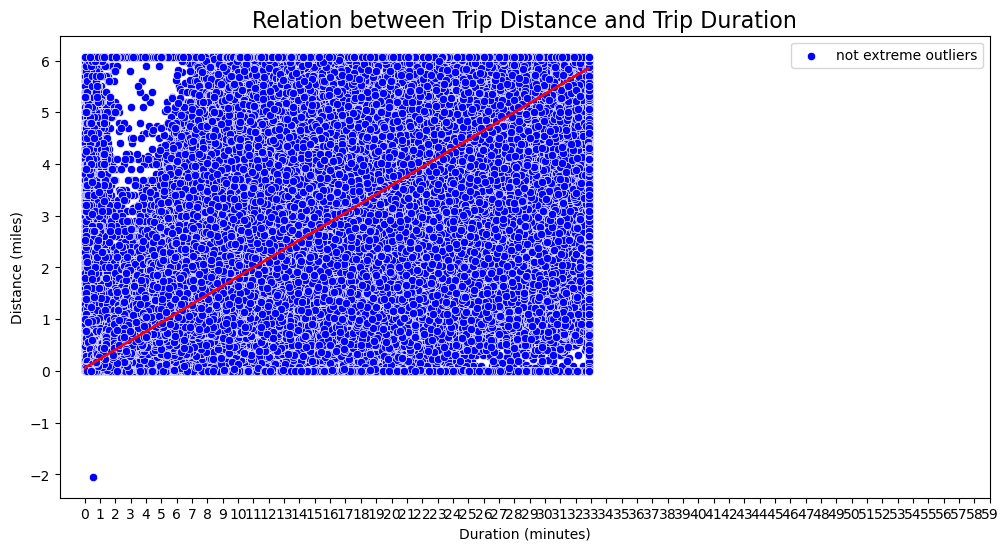

In [158]:
# Relationship between trip duration and trip distance to possibly create a new feature which is driving speed
plt.figure(figsize=(12,6))

sns.scatterplot(df, x='trip_duration_minutes', y='trip_distance', color='blue', label='not extreme outliers')

x, y = df['trip_duration_minutes'], df['trip_distance'] 
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red')

plt.xlabel('Duration (minutes)')
plt.ylabel('Distance (miles)')
plt.xticks(np.arange(0, 60))
plt.legend(loc ="upper right", prop={'size': 10})
plt.title('Relation between Trip Distance and Trip Duration', fontsize=16)
plt.show()

In [162]:
df['speed'] = (df['trip_distance'] / (df['trip_duration_minutes']/60)).round(2)

In [164]:
outliers = df[(df['speed']<5) | (df['speed']>70)][['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_distance', 'trip_duration_minutes', 'speed']]
print('Total extreme outliers : ', len(outliers))
outliers.sort_values(by='speed', ascending=True).head()

Total extreme outliers :  606879


,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,trip_duration_minutes,speed
4166134,2016-02-08 17:52:54,2016-02-08 17:53:27,-2.045,0.550000,-223.09
11143100,2016-02-28 22:05:05,2016-02-28 22:05:25,0.000,0.333333,0.00
11154584,2016-02-13 22:40:38,2016-02-13 22:40:53,0.000,0.250000,0.00
11154624,2016-02-13 22:38:10,2016-02-13 22:38:35,0.000,0.416667,0.00
224,2016-02-19 20:49:57,2016-02-19 20:50:43,0.000,0.766667,0.00


In [172]:
# Cap outliers
for col in ['speed']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

In [176]:
outliers = df[(df['speed']<5) | (df['speed']>70)][['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_distance', 'trip_duration_minutes', 'speed']]
print('Total extreme outliers : ', len(outliers))
outliers.sort_values(by='speed', ascending=True).head()

Total extreme outliers :  598420


,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,trip_duration_minutes,speed
11154624,2016-02-13 22:38:10,2016-02-13 22:38:35,0.0,0.416667,0.43
57,2016-02-01 00:00:01,2016-02-01 00:03:16,0.0,3.250000,0.43
11154584,2016-02-13 22:40:38,2016-02-13 22:40:53,0.0,0.250000,0.43
8008775,2016-02-25 10:37:44,2016-02-25 10:38:01,0.0,0.283333,0.43
8008898,2016-02-25 10:38:38,2016-02-25 10:38:57,0.0,0.316667,0.43


# 4. Exploratory Data Analysis (EDA)

In [189]:
#  Extract the hour of the day from the pickup and dropoff datetime column 
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['dropoff_hour'] = df['tpep_dropoff_datetime'].dt.hour

# Add a feature for the day of the week
df['pickup_day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek

df.head(2)

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,dropoff_longitude,dropoff_latitude,fare_amount,tip_amount,trip_duration_minutes,pickup_time,day_category,speed,pickup_hour,dropoff_hour,pickup_day_of_week
0,2016-02-25 17:24:20,2016-02-25 17:27:20,2,0.70,-73.947250,40.763771,Standard rate,-73.992012,40.735390,5.0,0.0,3.0,Evening,Weekdays,14.00,17,17,3
1,2016-02-25 23:10:50,2016-02-25 23:31:50,2,5.52,-73.983017,40.750992,Standard rate,-73.988586,40.758839,20.0,0.0,21.0,Night,Weekdays,15.77,23,23,3


In [191]:
# Skewness of numerical features using original column names
print("\nSkewnessof numericalfeatures:")
print(df[['trip_duration_minutes', 'fare_amount', 'trip_distance', 'pickup_day_of_week']].skew())


Skewnessof numericalfeatures:
trip_duration_minutes    0.949890
fare_amount              1.051196
trip_distance            1.087161
pickup_day_of_week      -0.039446
dtype: float64


- Skewness ≈ 0: normal distribution
- Positive Skewness (Skewness > 0): The distribution is right-skewed (long tail on the right), Most values are concentrated on the left
- Negative Skewness (Skewness < 0): The distribution is left-skewed (long tail on the left), Most values are concentrated on the right
- Magnitude of Skewness:
|Skewness| < 0.5: Approximately symmetric.
0.5 ≤ |Skewness| < 1: Moderately skewed.
|Skewness| ≥ 1: Highly skewed.
- trip_duration_minutes: moderately skewed
- fare amount and trip distance: right-skewed
- pickup_day_of_week: evenly distributed

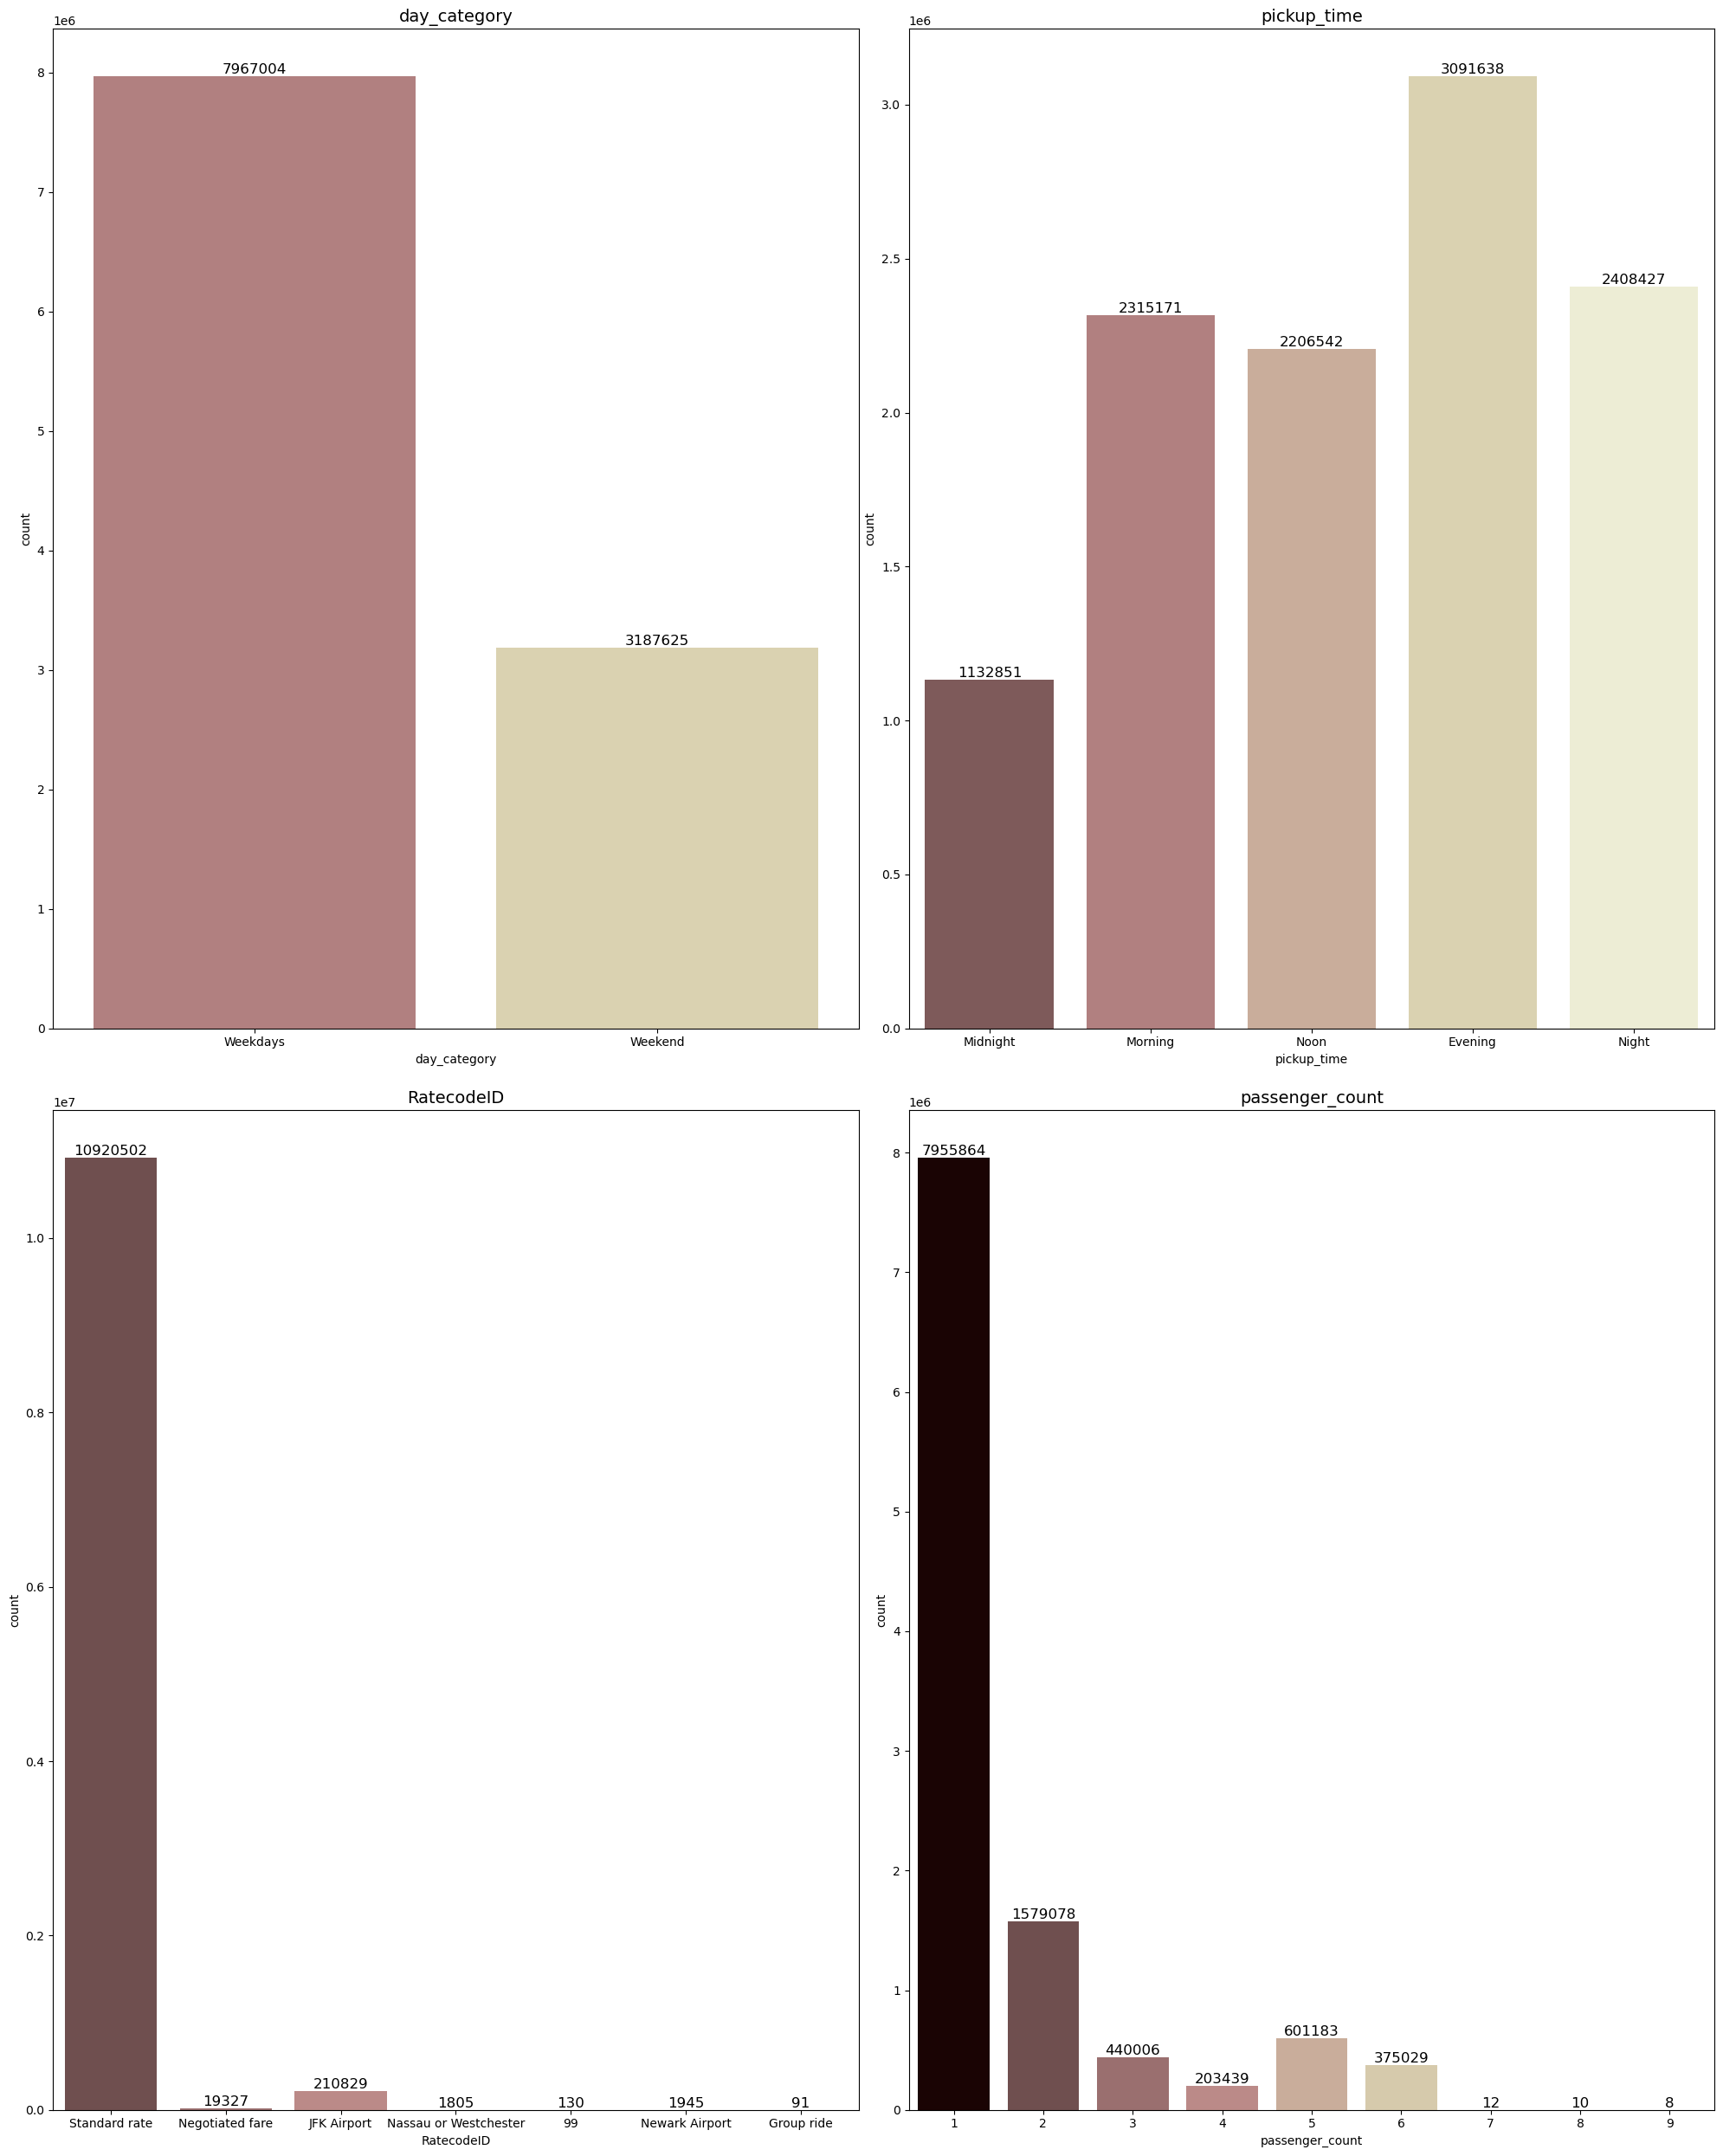

In [198]:
# Plotting categories to visualize them
cols = ['day_category', 'pickup_time', 'RatecodeID', 'passenger_count']

# Create subplots
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(20, 25))
axs = axs.flatten()

# Loop through the columns
for i, col in enumerate(cols):
    bars = sns.countplot(data=df, x=col, hue=col, palette='pink', ax=axs[i], legend=False)
    axs[i].set_title(col, fontsize=14)
    
    # Annotate bars with count values
    for bar in bars.patches:
        x_value = bar.get_x() + bar.get_width() / 2
        y_value = bar.get_height()
        label = "{:.0f}".format(y_value)
        axs[i].text(x_value, y_value, label, ha='center', va='bottom', fontsize=12) 

# Adjust layout
plt.tight_layout(w_pad=0.5, h_pad=2)
plt.show()

- Insight
- As we can see the highest number of ride occurs during weekdays and in the evening
- Most of the ride are at standard rate and the second highest category is ride to JFK Airport
- Most of the ride are counting one passenger, very few ride are at more the 6 passengers

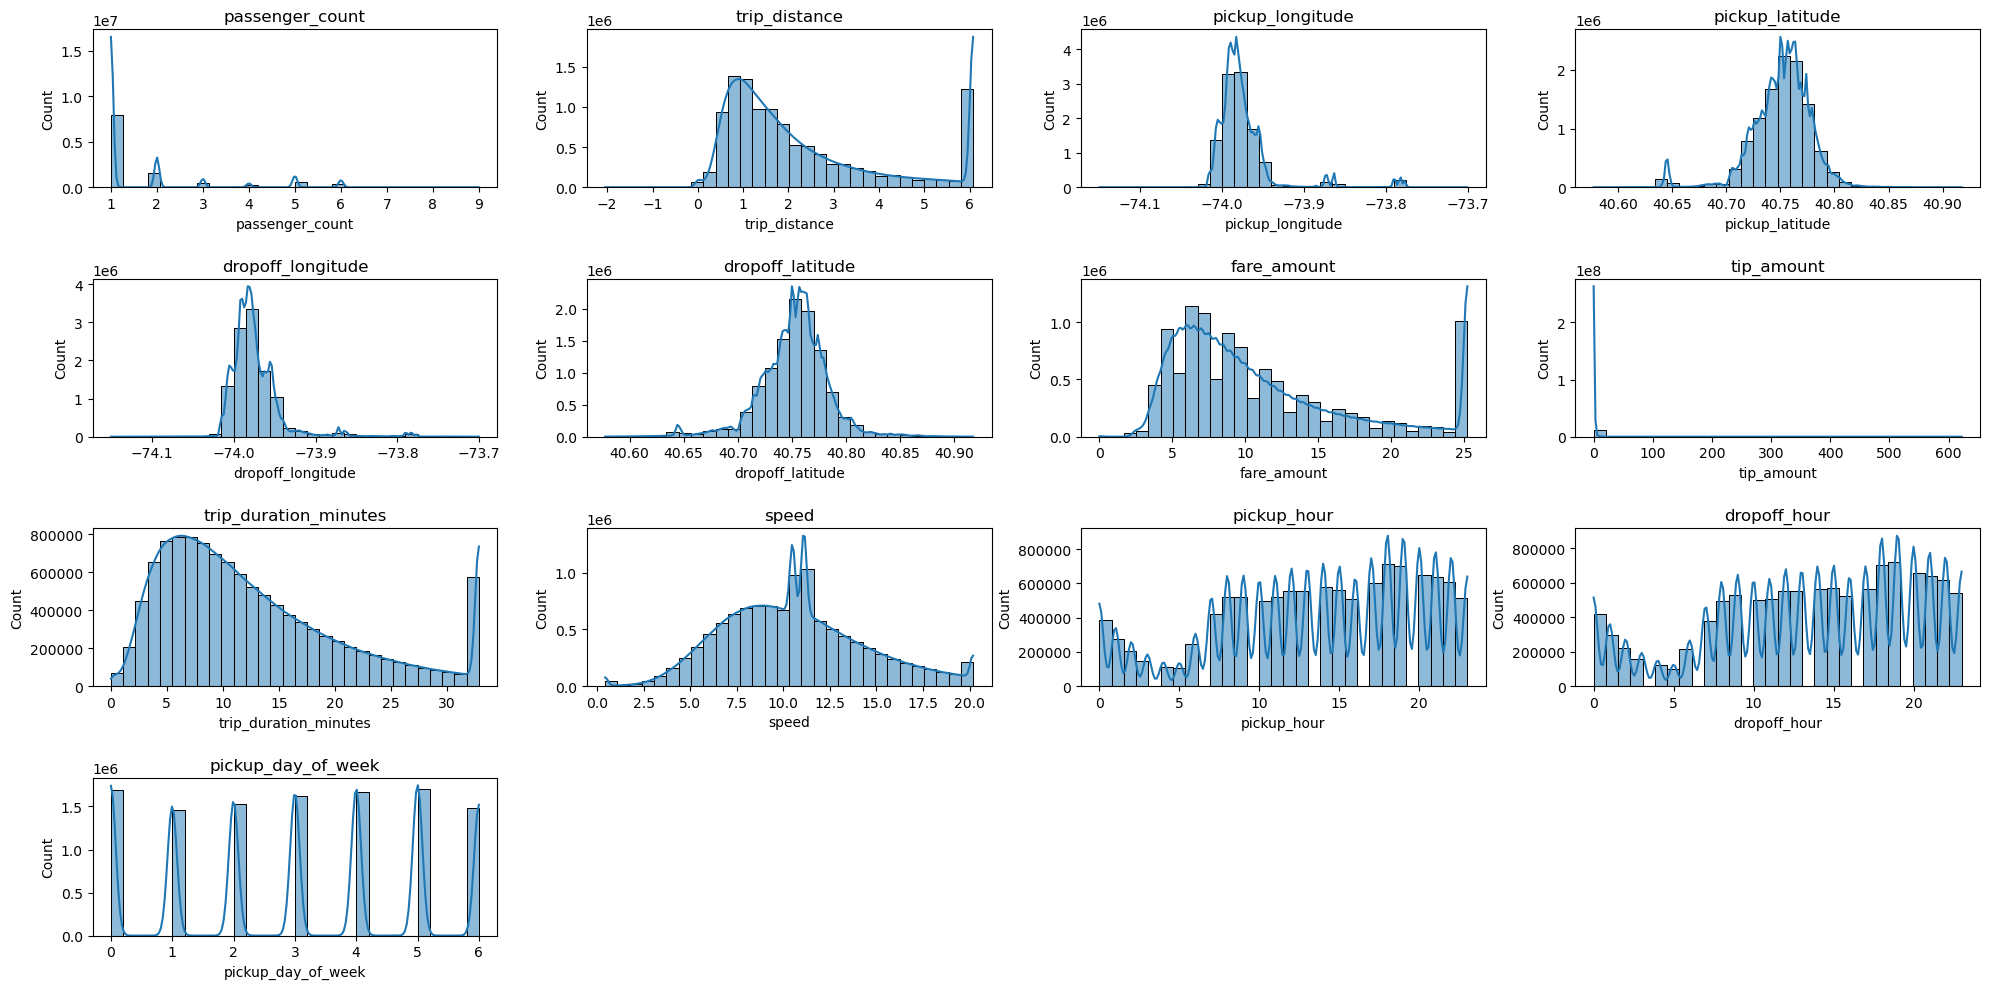

In [204]:
# Get numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns
num_features = len(num_cols)  # Total number of numerical features

# Define subplot grid size dynamically
rows = (num_features // 4) + (num_features % 4 > 0)  # Adjust rows dynamically
cols = min(4, num_features)  # Ensure it doesn't exceed 4 columns

# Create subplots dynamically based on available numerical features
fig, axs = plt.subplots(nrows=rows, ncols=cols, figsize=(20, 10))
axs = axs.flatten()  # Flatten the axes for easy indexing

# Loop through numerical columns and plot their distributions
for index, col in enumerate(num_cols):
    sns.histplot(df[col], ax=axs[index], kde=True, bins=30)
    axs[index].set_title(col, fontsize=12)

# Hide unused subplots
for i in range(len(num_cols), len(axs)):  # Hide empty subplots
    fig.delaxes(axs[i])

# Adjust layout for better visibility
plt.tight_layout(w_pad=0.5, h_pad=2)
plt.show()

$INSIGHTS$
- As we can see above the distribution are as follows:
- Passenger Count: The majority of trips have 1 passenger, with a steep drop-off for higher values. Few trips have more than 6 passengers.
- Trip Distance: The distribution is right-skewed, with most trips being short distances (under 5 miles), but some extreme outliers.
- Pickup & Dropoff Coordinates (Longitude & Latitude): These values form a tight normal distribution, corresponding to the NYC area, though some extreme values may be errors.
- Fare Amount: The majority of fares are under 20 dollars, but there are significant outliers above 600 dollars, suggesting data errors or rare long trips.
- Tip Amount: Most values are zero, but a few extreme outliers above $300, indicating possibly incorrect or high-value tips.
- Trip Duration (Minutes): The distribution is right-skewed, with most trips lasting between 0-30 minutes.
- Speed: Displays a near-normal distribution with most speeds ranging between 5-15 mph, likely reflecting urban traffic.
- Pickup & Dropoff Hour: Follows a bimodal pattern, with peaks in the morning (7-9 AM) and evening (4-8 PM), indicating commuting trends.
- Pickup Day of Week: Shows a uniform pattern across all days, suggesting no significant day-of-week effect.

In [ ]:
# Extract hour, day, and month from datetime
merged_df['pickup_hour'] = merged_df['tpep_pickup_datetime'].dt.hour
merged_df['pickup_day'] = merged_df['tpep_pickup_datetime'].dt.dayofweek  # 0=Monday, 6=Sunday
merged_df['pickup_month'] = merged_df['tpep_pickup_datetime'].dt.month

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Line plot for Fare Amount by Hour of the Day
sns.lineplot(x=merged_df['pickup_hour'], y=merged_df['fare_amount'], ax=axes[0], errorbar=None)
axes[0].set_title("Average Fare Amount by Hour of the Day")
axes[0].set_xlabel("Pickup Hour")
axes[0].set_ylabel("Fare Amount ($)")

# Line plot for Fare Amount by Day of the Week
sns.lineplot(x=merged_df['pickup_day'], y=merged_df['fare_amount'], ax=axes[1], errorbar=None)
axes[1].set_title("Average Fare Amount by Day of the Week")
axes[1].set_xlabel("Pickup Day (0=Monday, 6=Sunday)")

# Line plot for Fare Amount by Month
sns.lineplot(x=merged_df['pickup_month'], y=merged_df['fare_amount'], ax=axes[2], errorbar=None)
axes[2].set_title("Average Fare Amount by Month")
axes[2].set_xlabel("Pickup Month")

plt.show()

/var/folders/hk/z7y6hr3s1_vgrmjkcyh6cjs00000gn/T/ipykernel_347/2651345825.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  amount_by_time = df.groupby('pickup_time').agg(total_fare_amount=('fare_amount', 'sum'),
/var/folders/hk/z7y6hr3s1_vgrmjkcyh6cjs00000gn/T/ipykernel_347/2651345825.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=amount_by_time,


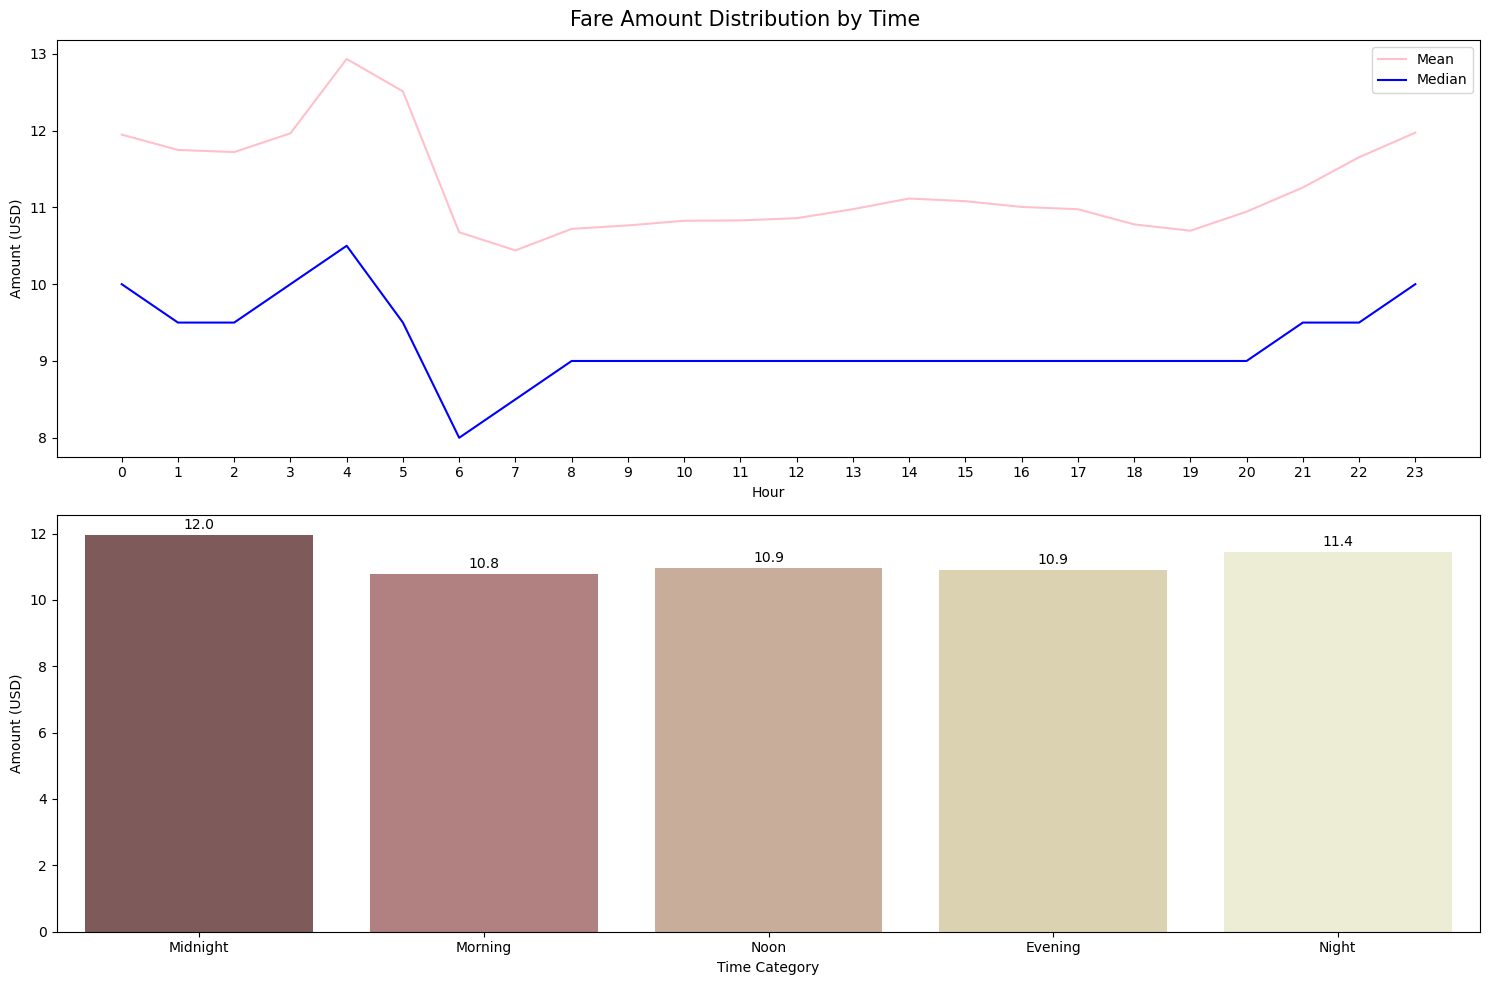

In [210]:
# Fare amount distribution by time
sort_time = ['Midnight', 'Morning', 'Noon', 'Evening', 'Night']
amount_by_hour = df.groupby(df['tpep_pickup_datetime'].dt.hour).agg(total_fare_amount=('fare_amount', 'sum'), 
                                                                    avg_fare_amount=('fare_amount', 'mean'), 
                                                                    median_fare_amount=('fare_amount', 'median')).reset_index()
amount_by_time = df.groupby('pickup_time').agg(total_fare_amount=('fare_amount', 'sum'), 
                                               avg_fare_amount=('fare_amount', 'mean'), 
                                               median_fare_amount=('fare_amount', 'median')).reindex(sort_time).reset_index().round(2)

plt.figure(figsize=(15,10))
plt.suptitle('Fare Amount Distribution by Time', fontsize=15)

plt.subplot(2,1,1)
sns.lineplot(data=amount_by_hour, 
             x='tpep_pickup_datetime', 
             y='avg_fare_amount', 
             color='pink',
             label = 'Mean')
sns.lineplot(data=amount_by_hour, 
             x='tpep_pickup_datetime', 
             y='median_fare_amount', 
             color='blue',
             label = 'Median')
plt.xlabel('Hour')
plt.xticks(np.arange(0,24,1))
plt.ylabel('Amount (USD)')


plt.subplot(2,1,2)
bars = sns.barplot(data=amount_by_time,
                   x='pickup_time', 
                   y='avg_fare_amount',
                   palette='pink')

for idx, bar in enumerate(bars.patches):
    x_value = bar.get_x() + bar.get_width() / 2
    y_value = bar.get_height() + 0.3
    label = "{:.1f}".format(amount_by_time['avg_fare_amount'].iloc[idx]) 
    plt.text(x_value, y_value, label, ha='center', va='center')
plt.xlabel('Time Category')
plt.ylabel('Amount (USD)')

plt.tight_layout()
plt.show()

$1.INSIGHTS$
- The pink line (mean fare amount) shows fluctuations, with a notable peak around 5-6 AM, likely due to airport trips or fewer available taxis.
- The blue line (median fare amount) is more stable, indicating that extreme outliers (e.g., very expensive fares) are influencing the mean.
- Late-night fares (after 10 PM) tend to increase, likely due to higher demand and surge pricing.
- Morning hours (6-8 AM) have the lowest median fares, possibly due to shorter commutes.

$1.INSIGHTS$
- Fares are categorized into time periods (Midnight, Morning, Noon, Evening, Night).
- The highest fares occur at Midnight ($12.0) and Night ($11.4), aligning with demand surges.
- Morning and Noon fares are slightly lower ($10.8-$10.9), reflecting more frequent but shorter rides (e.g., work commutes).
- Evening fares ($10.9) are moderate, likely due to post-work travel.

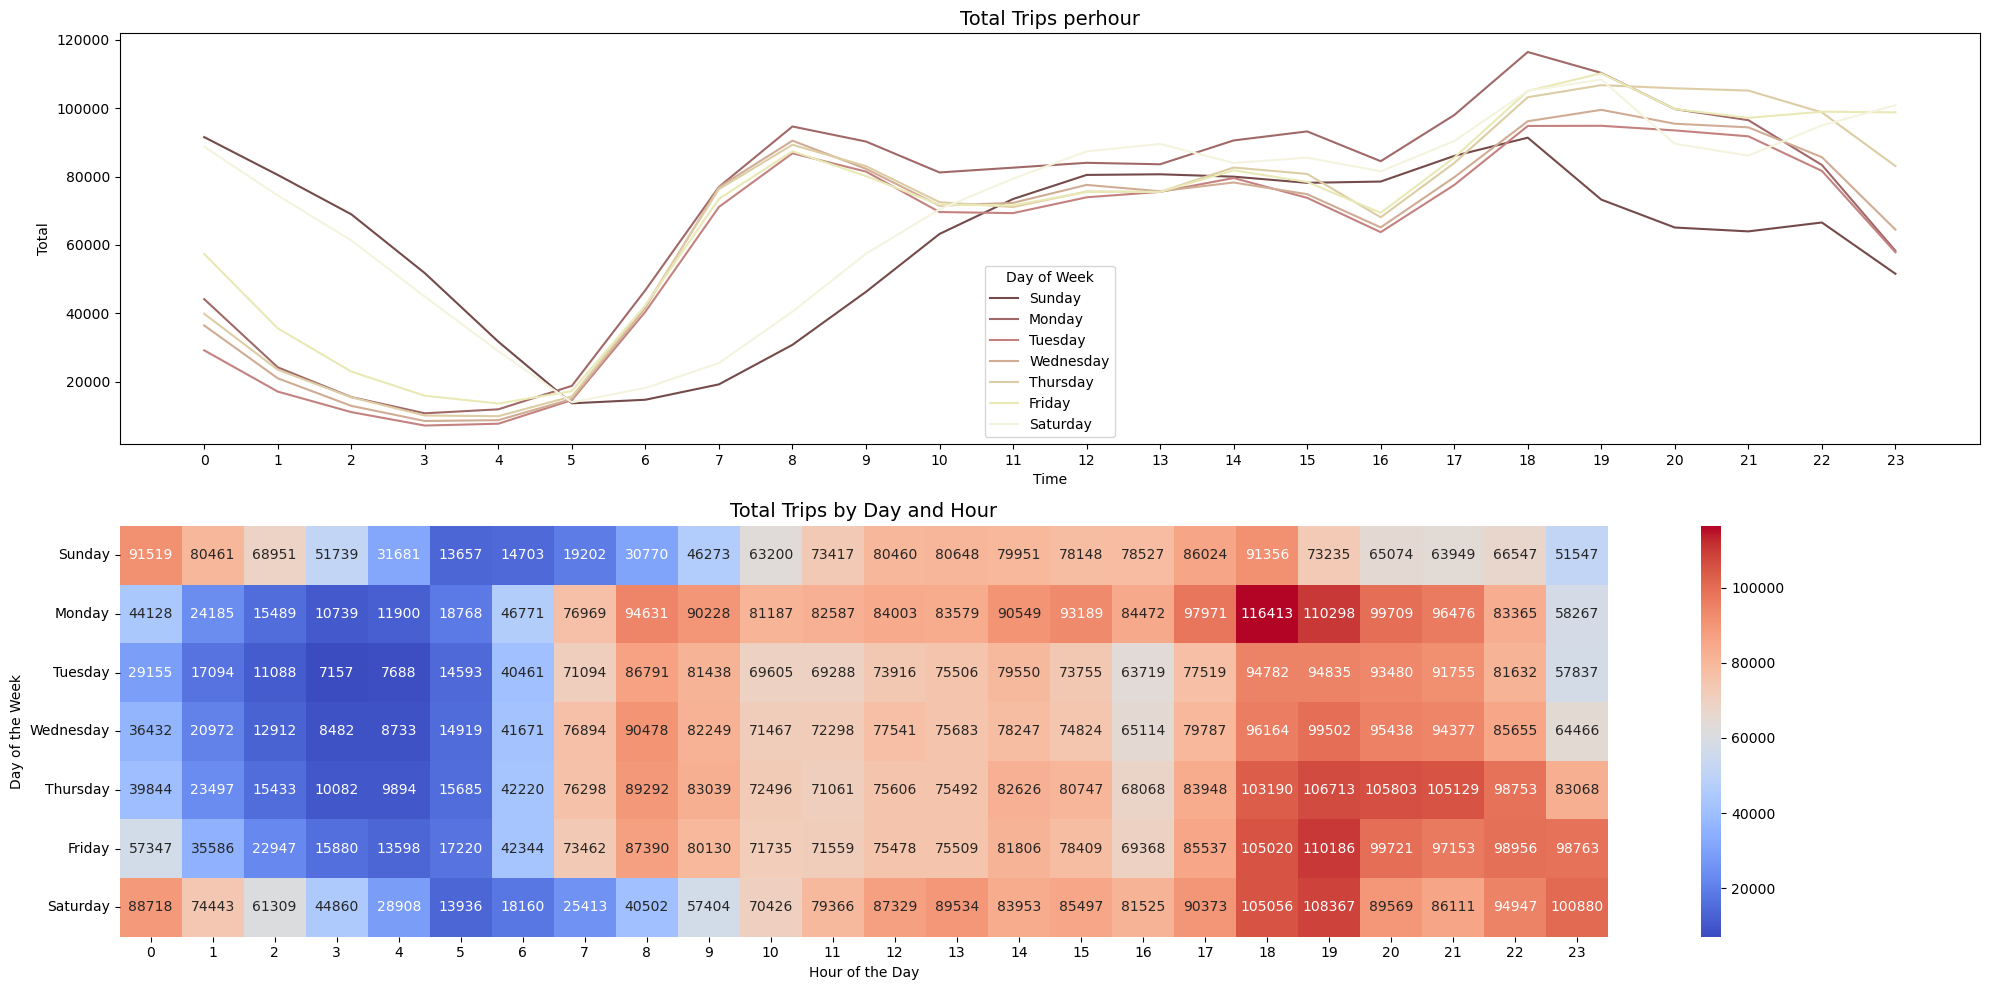

In [216]:
# Plotting trips by day and hours
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
cross = pd.crosstab(index=df['tpep_pickup_datetime'].dt.day_name(), columns=df['tpep_pickup_datetime'].dt.hour, margins=True).reindex(day_order)
cross.columns.name = None
cross.index.name = 'Day of Week'

melted_cross = cross.iloc[:,:-1].reset_index().melt(id_vars='Day of Week', var_name='hour', value_name='trips')
cross

plt.figure(figsize=(20,10))

plt.subplot(2, 1, 1)
sns.lineplot(data=melted_cross, 
             x='hour', 
             y='trips', 
             hue='Day of Week', 
             palette='pink')

plt.title('Total Trips perhour', fontsize=14)
plt.xlabel('Time')
plt.xticks(np.arange(0,24,1))
plt.ylabel('Total')

plt.subplot(2, 1, 2)
sns.heatmap(cross.iloc[:,:-1], cmap="coolwarm", annot=True, fmt='d')
plt.title('Total Trips by Day and Hour', fontsize=14)
plt.xlabel('Hour of the Day')
plt.ylabel('Day of the Week')

plt.tight_layout()
plt.show()

$INSIGHTS$
Insights from the Total Trips by Day and Hour Analysis
1. Peak Hours for Trips
- lowest trips is between 2 AM - 5 AM across all days.
- There is a sharp increase in trips starting from 6 AM, with trips peaking around 8-9 AM, aligning with morning commute hours.
- Another significant peak occurs between 5 PM - 7 PM, coinciding with the evening rush hour.
2. Day-wise Trip Patterns
- Weekends (Saturday & Sunday) show a higher number of trips during late-night hours (12 AM - 3 AM) compared to weekdays, likely due to nightlife and entertainment activities.
- Weekdays (Monday - Friday) have more structured peaks, with morning (8-9 AM) and evening (5-7 PM) rush hours being dominant.
- Monday and Tuesday have slightly lower trip volumes compared to other weekdays, suggesting lighter travel demand at the beginning of the week.
3. Heatmap Observations
- Friday and Saturday have the highest trip counts, particularly in the evening and late-night hours.
- Weekday afternoons (12 PM - 4 PM) see a gradual increase, but the highest intensity remains during the morning and evening rush hours.
- Sunday has a more spread-out distribution, with fewer extreme peaks but still relatively high late-night trip counts.
4. Business vs. Leisure Travel Patterns
- The distinct peaks in weekday trips suggest that many rides are work-related commutes.
- The higher number of late-night trips on weekends suggests increased social and leisure activities.

In [ ]:
#GEOGRAPHICAL HEATMAP

!pip install folium

#Heatmap Pick-Up
import folium
from folium.plugins import HeatMap
from folium.features import Choropleth

# Suppose you have a DataFrame df with columns: pickup_latitude, pickup_longitude
# Create a list of [lat, lon] points:
pickup_points = df[['pickup_latitude', 'pickup_longitude']].dropna().values.tolist()

# Initialize a Folium map centered on NYC
m = folium.Map(
    location=[40.7128, -74.0060], # Proposed from ChatGPT
    zoom_start=12,                
    tiles='CartoDB positron'       
)

# Custom gradient
custom_gradient = {
    0.2: 'blue',
    0.4: 'lime',
    0.6: 'yellow',
    0.8: 'orange',
    1.0: 'red'
}

# Add a heatmap layer
HeatMap(pickup_points,
        radius=5,   # adjust for density
        blur=3,
        max_zoom=15
       ).add_to(m)

# Display in a Jupyter notebook (m) or save to HTML
m.save("pickup_heatmap.html")
m

#Heatmap Drop-Off
# Suppose you have a DataFrame df with columns: pickup_latitude, pickup_longitude
# Create a list of [lat, lon] points:
dropoff_points = df[['dropoff_latitude', 'dropoff_longitude']].dropna().values.tolist()

# Initialize a Folium map centered on NYC
m = folium.Map(
    location=[40.7128, -74.0060], # Proposed from ChatGPT
    zoom_start=12,                
    tiles='CartoDB positron'       
)

# Custom gradient
custom_gradient = {
    0.2: 'blue',
    0.4: 'lime',
    0.6: 'yellow',
    0.8: 'orange',
    1.0: 'red'
}

# Add a heatmap layer
HeatMap(pickup_points,
        radius=5,   # adjust for density
        blur=3,
        max_zoom=15
       ).add_to(m)

# Display in a Jupyter notebook (m) or save to HTML
m.save("pickup_heatmap.html")
m

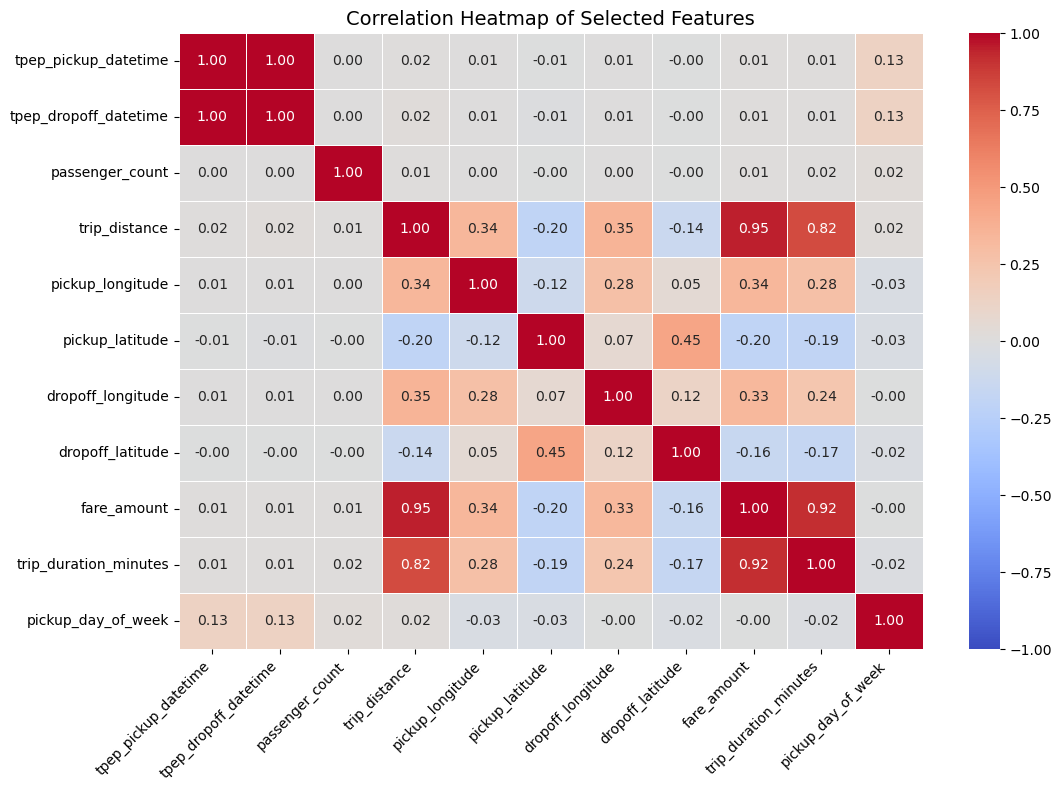

In [229]:
# Enhanced Correlation Heatmap
selected_columns = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count",
    "trip_distance", "pickup_longitude", "pickup_latitude",
    "dropoff_longitude", "dropoff_latitude", "fare_amount", "trip_duration_minutes", "pickup_day_of_week"
]
# Compute correlation matrix for selected columns
corr_matrix = df[selected_columns].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
    vmin=-1, vmax=1, linewidths=0.5, annot_kws={"size":10}
)
plt.xticks(rotation=45, ha='right')
plt.title("Correlation Heatmap of Selected Features", fontsize=14)
plt.show()

$INSIGHTS$
- From Correlation heatmap
1. Strong Positive Correlations
Fare Amount vs. Trip Distance (0.95): Longer trips are directly associated with higher fare amounts, which is expected as fare is primarily distance-based.
Fare Amount vs. Trip Duration (0.92): Longer trips also tend to have higher fares, reinforcing the link between trip duration and cost.
Trip Distance vs. Trip Duration (0.82): Longer distances usually correspond to longer travel times, confirming logical consistency in trip data.
2. Moderate Positive Correlations
Trip Distance vs. Dropoff Longitude (0.35): There is a moderate relationship, suggesting that longer trips involve significant longitude changes, possibly indicating cross-city travel.
Trip Distance vs. Pickup Longitude (0.34): Similar to the above, meaning longer trips often involve broader geographical shifts.
Fare Amount vs. Dropoff Longitude (0.33): There is a moderate relationship, suggesting that taxi rides with more significant longitude changes tend to be more expensive.
3. Negative Correlations
Trip Distance vs. Pickup Latitude (-0.20): Slight negative correlation, indicating that certain latitudinal locations may have shorter trips on average.
Fare Amount vs. Pickup Latitude (-0.20): Suggests that fares tend to be lower in specific latitudinal zones, possibly due to trip density in urban areas.
4. Weak or No Correlation
Passenger Count vs. Fare Amount (0.01): There is almost no relationship between the number of passengers and fare amount, which aligns with the standard taxi pricing model that primarily considers distance and time.
Pickup and Dropoff Times vs. Fare/Trip Distance (~0.01-0.02): Indicates that the time of the trip itself does not strongly influence fare or trip distance beyond peak-hour pricing effects.

$TAKEAWAY$
- Key Takeaways
- Trip distance and trip duration are the two strongest factors influencing fare amount.
- Geographical features such as longitude and latitude show moderate influence on trip distance and fare.
- Passenger count has minimal impact on fare, which aligns with standard taxi pricing structures.
- Time-related features (pickup/dropoff times) have little correlation with fare or trip distance.

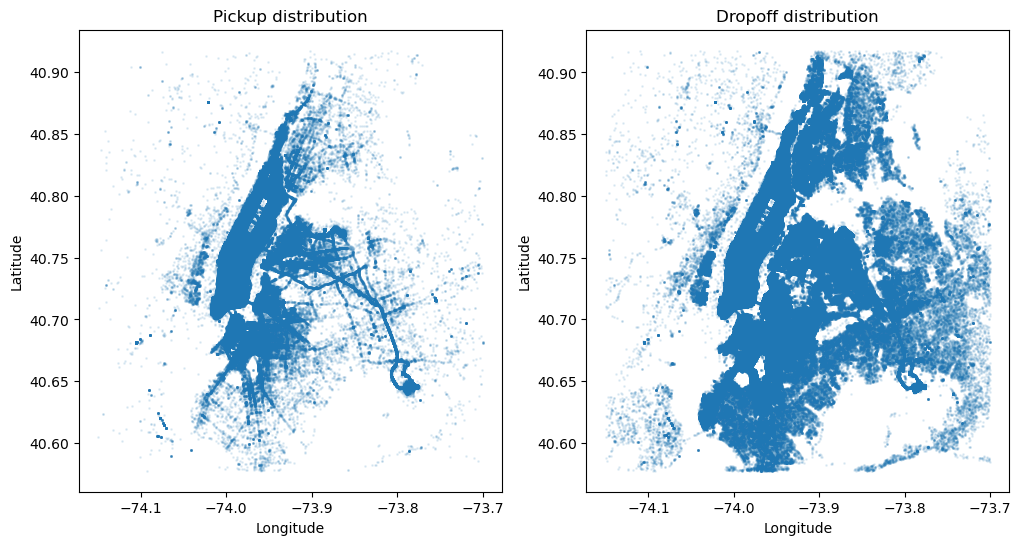

In [233]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.scatter(data=df, x='pickup_longitude', y='pickup_latitude', s=1, alpha=0.1)
plt.title('Pickup distribution')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.subplot(1,2,2)
plt.scatter(data=df, x='dropoff_longitude', y='dropoff_latitude', s=1, alpha=0.1)
plt.title('Dropoff distribution')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

# 5. Predictive Modelling

## 5.1 Model 1: Predict Taxi Fare

- Creating and Training a Logistic Regression model using LogisticRegression from scikit-learn.
We make predictions on the test set using the trained model.

In [246]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn import tree

In [248]:
# Logistic regression model testing

# Select relevant features and target variable
features = ["passenger_count", "trip_distance", "pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude"]
target = "fare_amount"

# Independent vs dependent variable
X = df[features]
y = df[target]

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Model Performance Metrics:
Mean Absolute Error (MAE): 1.34
Mean Squared Error (MSE): 3.92
Root Mean Squared Error (RMSE): 1.98
R² Score: 0.9003


$MODEL$ $EVALUATION$
1. Model Accuracy: R² Score (0.9003) This is quiteee good!!
The R² score (0.9003) means that 90.03% of the variance in fare amount can be explained by the selected features.
This is a strong fit, indicating that trip distance, location, and passenger count are highly relevant in predicting fare amount.
However, the remaining 9.97% is unexplained variance, which could be due to missing features (e.g., traffic conditions, time of day, tolls, or surge pricing).
2. Model Error Metrics
Mean Absolute Error (MAE) = 1.34
- On average, the model’s predictions deviate by 1.34 doll from the actual fare.
Mean Squared Error (MSE) = 3.92
- This is the average squared difference between actual and predicted fares. A lower MSE suggests fewer large errors.
Root Mean Squared Error (RMSE) = 1.98
- The model’s predictions typically have an error of around 1.98 doll.
- Since the average taxi fare is likely higher than 10 dollar, an RMSE of 1.98 doll is relatively low, meaning the model makes reasonably accurate predictions.

- To see if the model perform better
- We will add the features day_of_week and week_hours

In [270]:
# Convert datetime column to datetime format
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

# Extract hour of the day and encode it cyclically
df["hour"] = df["tpep_pickup_datetime"].dt.hour
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)  # Cyclical encoding
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# Extract day of the week
df["day_of_week"] = df["tpep_pickup_datetime"].dt.dayofweek  # Monday=0, Sunday=6

# One-hot encode day_of_week
df = pd.get_dummies(df, columns=["day_of_week"], prefix="day", drop_first=True)

# Define features and target variable, ensuring only numerical `day_` columns are selected
features = [
    "passenger_count", "trip_distance", 
    "pickup_longitude", "pickup_latitude", 
    "dropoff_longitude", "dropoff_latitude",
    "hour"
] + [col for col in df.select_dtypes(include=['int64', 'float64']).columns if col.startswith("day_")]

target = "fare_amount"

# Independent vs dependent variable
X = df[features]
y = df[target]

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display results
print(f"Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Model Performance Metrics:
Mean Absolute Error (MAE): 1.34
Mean Squared Error (MSE): 3.91
Root Mean Squared Error (RMSE): 1.98
R² Score: 0.9006


- It appears to change nothing
- The model hasn't improve

Model Performance Metrics:
Mean Absolute Error (MAE): 1.31
Mean Squared Error (MSE): 3.82
Root Mean Squared Error (RMSE): 1.95
R² Score: 0.9030


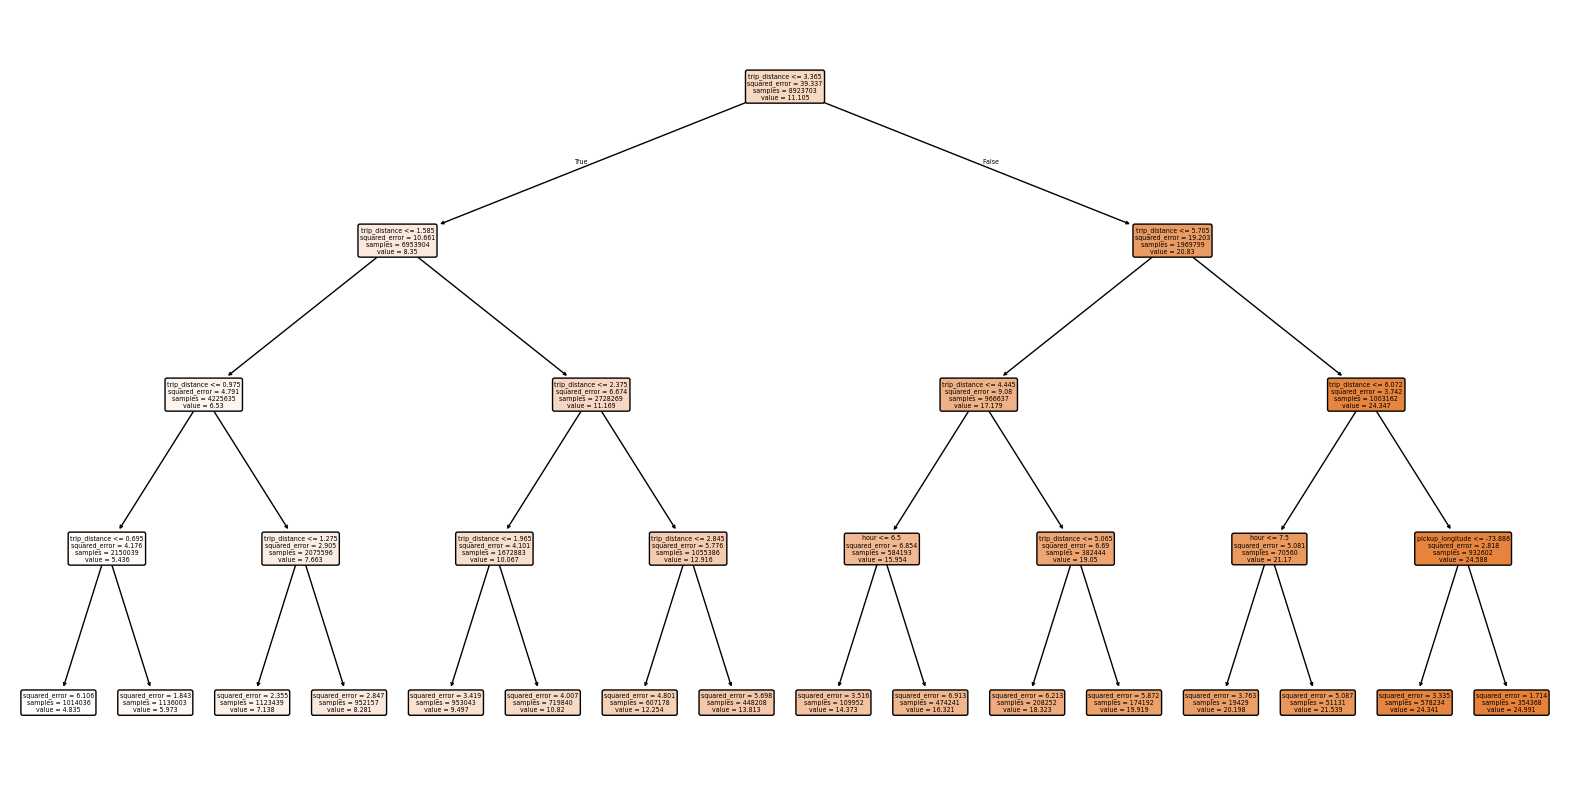

In [275]:
# Model testing with Decision three
from sklearn.tree import DecisionTreeRegressor

# Convert datetime column to datetime format
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

# Extract time-based features
df["hour"] = df["tpep_pickup_datetime"].dt.hour
df["day_of_week"] = df["tpep_pickup_datetime"].dt.dayofweek  # Monday=0, Sunday=6

# One-hot encode day_of_week
df = pd.get_dummies(df, columns=["day_of_week"], prefix="day", drop_first=True)

# Define features and target variable
features = [
    "passenger_count", "trip_distance", 
    "pickup_longitude", "pickup_latitude", 
    "dropoff_longitude", "dropoff_latitude",
    "hour"
] + [col for col in df.select_dtypes(include=['int64', 'float64']).columns if col.startswith("day_")]

target = "fare_amount"

# Split dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, random_state=42)

# Initialize and train the Decision Tree Regressor
clf = DecisionTreeRegressor(max_depth=4, random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate model performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display results
print(f"Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# Plot the Decision Tree
plt.figure(figsize=(20,10))
tree.plot_tree(clf, feature_names=X_train.columns, filled=True, rounded=True)
plt.show()

- Final Verdict
- The Decision Tree outperforms Linear Regression slightly across all metrics (MAE, MSE, RMSE, R²).
- However, the difference is not significant, meaning both models provide similar accuracy.
- The Decision Tree may handle non-linear relationships better, whereas Linear Regression is simpler and more interpretable.

$DECISION$ $TREE$
- The decision tree explains 90.30% of the variance in fare amount, whereas linear regression explains 90.03%. The difference is minor but shows the decision tree fits the data slightly better.

## 5.2 Model 2: Predict trip duration

Model Performance Metrics:
Mean Absolute Error (MAE): 3.21
Mean Squared Error (MSE): 19.01
Root Mean Squared Error (RMSE): 4.36
R² Score: 0.7136


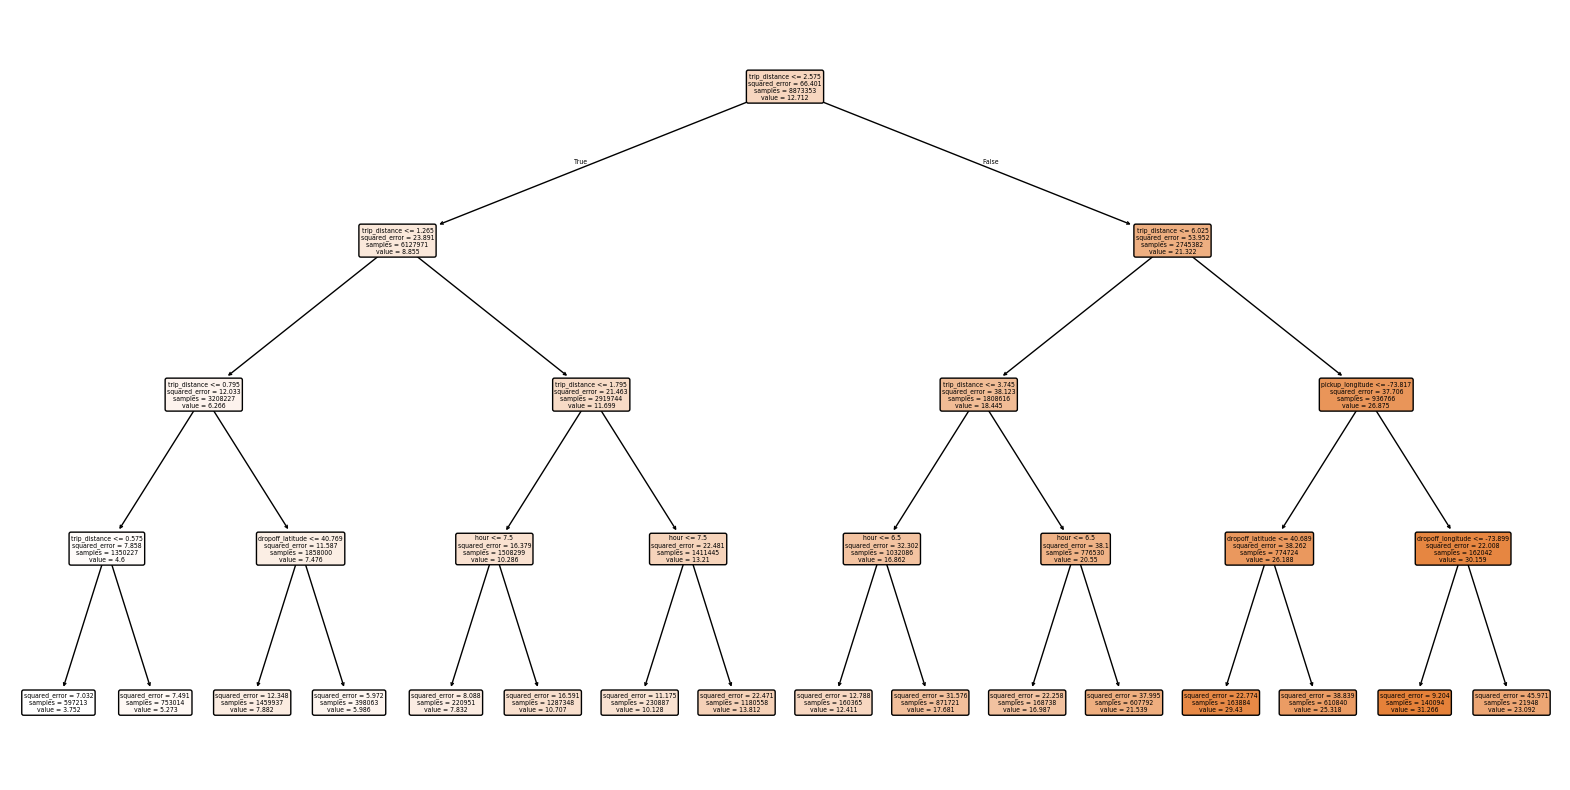

In [284]:
# Model building to predict trip duration

# Remove extreme outliers in trip duration (optional but recommended)
df = df[(df["trip_duration_minutes"] > 1) & (df["trip_duration_minutes"] < 120)]  # Keep only trips between 1-120 mins

# Extract time-based features
df["hour"] = df["tpep_pickup_datetime"].dt.hour
df["day_of_week"] = df["tpep_pickup_datetime"].dt.dayofweek  # Monday=0, Sunday=6

# One-hot encode day_of_week
df = pd.get_dummies(df, columns=["day_of_week"], prefix="day", drop_first=True)

# Define features and target variable
features = [
    "passenger_count", "trip_distance", 
    "pickup_longitude", "pickup_latitude", 
    "dropoff_longitude", "dropoff_latitude",
    "hour"
] + [col for col in df.select_dtypes(include=['int64', 'float64']).columns if col.startswith("day_")]

target = "trip_duration_minutes"

# Split dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, random_state=42)

# Initialize and train the Decision Tree Regressor
clf = DecisionTreeRegressor(max_depth=4, random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate model performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display results
print(f"Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# Plot the Decision Tree
plt.figure(figsize=(20,10))
tree.plot_tree(clf, feature_names=X_train.columns, filled=True, rounded=True)
plt.show()

$DECISION$ $TREE$ $INTERPRETATION$
- Model Prediction for trip duration
1. Mean Absolute Error (MAE) = 3.21
On average, the model's predictions deviate by 3.21 minutes from the actual trip duration.
This indicates a fairly accurate model, but there is room for improvement.
2. Mean Squared Error (MSE) = 19.01
The average squared error is 19.01, meaning that some predictions have large errors.
This suggests the presence of outliers or certain trips where the model performs poorly.
3. Root Mean Squared Error (RMSE) = 4.36
The typical prediction error is 4.36 minutes.
This means that while the model is generally accurate, some trips have significant prediction errors.
4. R² Score (Coefficient of Determination) = 0.7136
The model explains 71.36% of the variance in trip duration.
The remaining 28.64% of variance is unexplained, meaning important influencing factors are missing (e.g., traffic, weather conditions)

In [14]:
import pandas as pd

# Load the raw dataset
df = pd.read_csv("yellow_tripdata_2016-02.csv")

# Check if the dataset is correctly loaded
df.head(2)

# Remove negative fare amounts
df = df[df["fare_amount"] > 0]

# Remove trips with 0 passengers
df = df[df["passenger_count"] > 0]

# Convert datetime columns
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

# Calculate trip duration in minutes
df["trip_duration_minutes"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60

# Remove extreme trip durations (outliers)
df = df[(df["trip_duration_minutes"] > 1) & (df["trip_duration_minutes"] < 120)]

# Drop invalid longitude/latitude values (outside NYC bounding box)
df = df[
    (df["pickup_longitude"].between(-74.15, -73.70)) &
    (df["pickup_latitude"].between(40.57, 40.92)) &
    (df["dropoff_longitude"].between(-74.15, -73.70)) &
    (df["dropoff_latitude"].between(40.57, 40.92))
]

# Reset index
df = df.reset_index(drop=True)

print("Dataset reloaded and cleaned.")
df.head(2)
df.to_csv("cleaned_taxi_data.csv", index=False)

Dataset reloaded and cleaned.


In [34]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Extract time-based features
df["hour"] = df["tpep_pickup_datetime"].dt.hour
df["day_of_week"] = df["tpep_pickup_datetime"].dt.dayofweek

# One-hot encode day_of_week
df = pd.get_dummies(df, columns=["day_of_week"], prefix="day", drop_first=True)

# Fixed Feature Selection: Ensures only numerical `day_` columns are included
features = ["passenger_count", "trip_distance", "pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude", "hour"]

target = "trip_duration_minutes"

# Split dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate model performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display results
print(f"Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Model Performance Metrics:
Mean Absolute Error (MAE): 3.00
Mean Squared Error (MSE): 20.98
Root Mean Squared Error (RMSE): 4.58
R² Score: 0.7801


$RANDOM$ $FOREST$ $INTERPRETATION$ $&$ $COMPARISON$
- Model Prediction for trip duration
1. Mean Absolute Error (MAE)
- Random Forest: 3.00 minutes
- Decision Tree: 3.21 minutes
- Interpretation: Random Forest is slightly more accurate with lower absolute errors.
2. Mean Squared Error (MSE)
- Random Forest: 20.98
- Decision Tree: 19.01
- Interpretation: Decision Tree has lower MSE, meaning it makes fewer extreme errors.
3. Root Mean Squared Error (RMSE)
- Random Forest: 4.58 minutes
- Decision Tree: 4.36 minutes
- Interpretation: Decision Tree has slightly lower RMSE, indicating fewer large errors.
4. R² Score
- Random Forest: 0.7801 (78.01%)
- Decision Tree: 0.7136 (71.36%)
- Interpretation: Random Forest explains more variance in trip duration, making it a better model overall.

*CONCLUSION*
- Random Forest performs better overall due to higher accuracy and better variance explanation.
- Decision Tree is slightly better in handling extreme errors (lower MSE and RMSE).

# 6. Interactive Fare Estimation Tool

In [45]:
pip install --upgrade ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 30.1 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.6
    Uninstalling widgetsnbextension-3.6.6:
      Successfully uninstalled widgetsnbextension-3.6.6
  Attempting uninstall: jupyterlab-widgets
    Found existing installation: jupyterlab-widgets 1.0.0
    Uninstalling jupyterlab-widgets-1.0.0:
      Successfully uninstalled jupyterlab-widgets-1.0.0
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.8.1
    Uninstalling ipywidgets-7.8.1:
      Successfully uninstalled ipywidgets-7.8.1
Note: you may need to restart the kernel to use updated packages.


In [2]:
import ipywidgets
ipywidgets.Widget.widget_types
from IPython.display import display
display(ipywidgets.HTML("<script>Jupyter.notebook.kernel.restart_and_run_all();</script>"))

/var/folders/hk/z7y6hr3s1_vgrmjkcyh6cjs00000gn/T/ipykernel_25167/594015329.py:2: DeprecationWarning: Widget.widget_types is deprecated.
  ipywidgets.Widget.widget_types


HTML(value='<script>Jupyter.notebook.kernel.restart_and_run_all();</script>')

In [8]:
import pandas as pd
df = pd.read_csv("cleaned_taxi_data.csv")

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import VBox
from IPython.display import display, clear_output
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ensure datetime columns are properly formatted
df = df.copy()
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

# Compute trip duration in minutes
df["trip_duration_minutes"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60

# Extract time-based features
df["hour"] = df["tpep_pickup_datetime"].dt.hour
df["day_of_week"] = df["tpep_pickup_datetime"].dt.dayofweek  # Monday=0, Sunday=6

# One-hot encode day_of_week
df = pd.get_dummies(df, columns=["day_of_week"], prefix="day", drop_first=True)

# Define features and target variable
features = ["passenger_count", "trip_distance", "pickup_longitude", "pickup_latitude", 
            "dropoff_longitude", "dropoff_latitude", "trip_duration_minutes"]

target = "fare_amount"

# Split dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, random_state=42)

# Initialize and train the Decision Tree model
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = tree_model.predict(X_test)

# Model performance evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Model Performance:\nMAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.4f}")

# Set min and max values for sliders
slider_params = {
    "passenger_count": (X_train["passenger_count"].min(), X_train["passenger_count"].max(), 1),
    "trip_distance": (X_train["trip_distance"].min(), X_train["trip_distance"].max(), 1),
    "pickup_longitude": (X_train["pickup_longitude"].min(), X_train["pickup_longitude"].max(), 0.01),
    "pickup_latitude": (X_train["pickup_latitude"].min(), X_train["pickup_latitude"].max(), 0.01),
    "dropoff_longitude": (X_train["dropoff_longitude"].min(), X_train["dropoff_longitude"].max(), 0.01),
    "dropoff_latitude": (X_train["dropoff_latitude"].min(), X_train["dropoff_latitude"].max(), 0.01),
    "trip_duration_minutes": (X_train["trip_duration_minutes"].min(), X_train["trip_duration_minutes"].max(), 1)
}

# Create sliders
sliders = {key: widgets.FloatSlider(min=v[0], max=v[1], step=v[2], value=X_train[key].mean(), description=key.replace("_", " ").title()) 
           for key, v in slider_params.items()}

fare_amount_slider = widgets.FloatSlider(min=y_train.min(), max=y_train.max(), step=1, value=y_train.mean(), description="Fare Amount")

# Output widget for displaying predictions
output = widgets.Output()

# Prediction function
def predict_fare(passenger_count, trip_distance, pickup_longitude, pickup_latitude, 
                 dropoff_longitude, dropoff_latitude, trip_duration_minutes, fare_amount):
    with output:
        clear_output(wait=True)
        input_data = np.array([[passenger_count, trip_distance, pickup_longitude, pickup_latitude, 
                                dropoff_longitude, dropoff_latitude, trip_duration_minutes]])
        predicted_fare = tree_model.predict(input_data)[0]
        print(f"Predicted Fare Amount: ${predicted_fare:.2f}")

# Create interactive widget
interactive_plot = widgets.interactive(predict_fare, **sliders, fare_amount=fare_amount_slider)

# Display the interactive interface
display(VBox([interactive_plot, output]))

Model Performance:
MAE: 0.46, RMSE: 104.05, R²: 0.0079


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import VBox
from IPython.display import display, clear_output
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ensure datetime columns are properly formatted
df = df.copy()
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

# Fixing unrealistic values for fare amount
for col in ['fare_amount']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

# Fixing unrealistic value for trip distance and Capping outliers
for col in ['trip_distance']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

# Drop all the points outside the bounding box of newyork city for pickups

df = df[~((df.pickup_longitude <= -74.15) | (df.pickup_latitude <= 40.5774) | \
              (df.pickup_longitude >= -73.7004) | (df.pickup_latitude >= 40.9176))]

# Reinitialize index after suppression
df = df.reset_index(drop=True)


# Drop all the points outside the bounding box of newyork city for dropoff
df = df[~((df.dropoff_longitude <= -74.15) | (df.dropoff_latitude <= 40.5774) | \
              (df.dropoff_longitude >= -73.7004) | (df.dropoff_latitude >= 40.9176))]

# Reinitialize index after suppression
df = df.reset_index(drop=True)
# Compute trip duration in minutes
df["trip_duration_minutes"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60

# Filter out extreme outliers in trip duration
df = df[(df["trip_duration_minutes"] > 1) & (df["trip_duration_minutes"] < 120)]

# Extract time-based features
df["hour"] = df["tpep_pickup_datetime"].dt.hour
df["day_of_week"] = df["tpep_pickup_datetime"].dt.dayofweek  # Monday=0, Sunday=6

# Encode time features (Cyclic Encoding for Hour)
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# One-hot encode day_of_week
df = pd.get_dummies(df, columns=["day_of_week"], prefix="day", drop_first=True)

# Define features and target variable
features = ["passenger_count", "trip_distance", "pickup_longitude", "pickup_latitude", 
            "dropoff_longitude", "dropoff_latitude", "trip_duration_minutes", "hour_sin", "hour_cos"]

# Add one-hot encoded day variables dynamically
features += [col for col in df.columns if col.startswith("day_")]

target = "fare_amount"

# Standardize Continuous Variables (Scale Longitude & Latitude)
scaler = StandardScaler()
df[["pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude"]] = scaler.fit_transform(
    df[["pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude"]]
)

# Split dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, random_state=42)

# Initialize and train the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Model performance evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Model Performance:\nMAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.4f}")

# Save cleaned dataset to prevent data loss
df.to_csv("cleaned_taxi_data.csv", index=False)

# Set min and max values for sliders
slider_params = {
    "passenger_count": (X_train["passenger_count"].min(), X_train["passenger_count"].max(), 1),
    "trip_distance": (X_train["trip_distance"].min(), X_train["trip_distance"].max(), 0.1),
    "pickup_longitude": (X_train["pickup_longitude"].min(), X_train["pickup_longitude"].max(), 0.01),
    "pickup_latitude": (X_train["pickup_latitude"].min(), X_train["pickup_latitude"].max(), 0.01),
    "dropoff_longitude": (X_train["dropoff_longitude"].min(), X_train["dropoff_longitude"].max(), 0.01),
    "dropoff_latitude": (X_train["dropoff_latitude"].min(), X_train["dropoff_latitude"].max(), 0.01),
    "trip_duration_minutes": (X_train["trip_duration_minutes"].min(), X_train["trip_duration_minutes"].max(), 1)
}

# Create sliders
sliders = {key: widgets.FloatSlider(min=v[0], max=v[1], step=v[2], value=X_train[key].mean(), description=key.replace("_", " ").title()) 
           for key, v in slider_params.items()}

fare_amount_slider = widgets.FloatSlider(min=y_train.min(), max=y_train.max(), step=1, value=y_train.mean(), description="Fare Amount")

# Output widget for displaying predictions
output = widgets.Output()

# Prediction function
def predict_fare(passenger_count, trip_distance, pickup_longitude, pickup_latitude, 
                 dropoff_longitude, dropoff_latitude, trip_duration_minutes, fare_amount):
    with output:
        clear_output(wait=True)
        input_data = np.array([[passenger_count, trip_distance, pickup_longitude, pickup_latitude, 
                                dropoff_longitude, dropoff_latitude, trip_duration_minutes]])
        predicted_fare = rf_model.predict(input_data)[0]
        print(f"Predicted Fare Amount: ${predicted_fare:.2f}")

# Create interactive widget
interactive_plot = widgets.interactive(predict_fare, **sliders, fare_amount=fare_amount_slider)

# Display the interactive interface
display(VBox([interactive_plot, output]))

Model Performance:
MAE: 0.27, RMSE: 0.64, R²: 0.9896


$Interpretation$ $of$ $Slider$ $Model$ $Performance$
1. Mean Absolute Error (MAE) = 0.27
On average, the model's predictions deviate by only 0.27 doll from the actual fare.
This indicates high accuracy in fare estimation.
2. Root Mean Squared Error (RMSE) = 0.64
The typical prediction error is 0.64 doll, showing minimal variation in predictions.
A lower RMSE suggests that the model has low variance and is making consistent predictions.
3. R² Score = 0.9896
The model explains 98.96% of the variance in fare amount, meaning it almost perfectly fits the data.
A very high R² suggests that most influencing factors are well captured by the model.

# 7. Conclusion

- As per the result we had when training various model to predict fare amount and to predict trip distance, we had great result, meaning that it can be used as a tool for taxi customers as usually we don't know how much a taxi ride will cost in contrary with an uber ride. It can be used by creating an application for customers an having this algorithm running and telling customers what is the fare amount according to the trip distance and time/day it is.
- Data Analysis Insights: TTrip duration and fare amount showed a strong correlation, necessitating precise feature selection. Time-based effects (hour of the day, day of the week) influenced fares, leading to cyclic encoding for time variables. Geospatial data (latitude/longitude) required standardization to enhance model performance.
- Final Interactive Model Performance: The latest slider-based fare prediction model achieved: MAE: 0.27 = Predictions deviate on average by only $0.27. RMSE: 0.64 = The model makes highly consistent predictions. R² Score: 0.9896 = The model explains 98.96% of fare variance, making it extremely accurate.
- Random Forest Performed better for predicting trip distance and DecisionTree performed better for predicting fare amount.
- With the data we have, I'll be great to explore density, predict density for taxi customers could be an interesting tool, because of the limitation of this work I wasn't able to do it... Also using real-time traffic data to enhance predictions or integrating user reviews could be interesting.
- For Further analysis: optimize hyperparameters in machine learning models. Integrate external factors like traffic and weather for better prediction accuracy. Deploy refined models in real-time applications for enhanced user experience and operational efficiency.

# 8. DISCLAIMER
- Chat gpt has been used to correct some codes or to optimize